# 03 — Toronto's Political Neighbourhoods: Interpreting Model 8F

This notebook picks up where `explore_neighbourhood_clusters.ipynb` left off. That notebook
built and compared many candidate clustering models of Toronto's 585 census tracts, using
their voting behaviour across three recent elections (the 2023 mayoral race, the 2025 Ontario
election, and the 2025 federal election). **This notebook does not re-run that model search.**
Its only job is to take the model that was chosen — **8F** — and interpret it in enough depth
to support a data-journalism piece on Toronto's political geography.

## What is Model 8F?

- **k = 5** clusters (five political neighbourhood groups).
- Each tract is described by a **50/50 blend** of two feature sets:
  - **City-relative deviations** — how a tract's vote shares and turnout compare to the
    *citywide* average, in percentage points.
  - **Within-riding-relative deviations** — how the same tract compares to the vote-weighted
    result of *its own* municipal ward / provincial riding / federal riding.
- Both halves are block-weighted (equal weight per election) and reduced with PCA before
  k-means clustering (`random_state=42`, `n_init=30`) — see §8E–8F of the reference notebook
  for the full derivation.

**Why this model, in one line:** a pure city-relative model conflates "safe NDP riding voting
slightly below its own historic norm" with "genuinely swingy tract" — it only sees the citywide
picture. A pure riding-residual model does the opposite: it can call a tract that is 70% NDP
in a heavily NDP riding "unremarkable" just because it matches its neighbours. The 50/50 blend
keeps both signals on the table at once, which is what lets a group like the high-turnout
Civic Liberals (§3) show up as genuinely distinct rather than being absorbed into
whichever riding it happens to sit in.

## Reading guide

- **The unit of analysis is the census tract, not the voter.** A cluster is a description of
  what a *neighbourhood's aggregate vote* looked like, not a claim about the people who live
  there or how any individual voted.
- We do not claim or test causality between demographics and voting. Where a cluster's
  demographic profile lines up with its political profile, we describe it as an *association*,
  not a cause.
- We are careful with visible-minority, citizenship, immigration, and income variables —
  neutral, descriptive language throughout (e.g. "below the city average", "overrepresented"),
  never loaded terms like "immigrant neighbourhood" or "working-class" unless the numbers
  actually support that specific claim.
- **Cluster order and colour are fixed once, in §2, and used identically everywhere after
  that** — every table, chart, map, and legend in this notebook orders the five groups from
  most progressive to most conservative and colours them from the same five-colour palette.
  See §2's "Cluster metadata" subsection for exactly how that order and those colours were
  chosen.

## Loading Model 8F

`02_model_exploration.ipynb` saves the tract-level Model 8F assignment directly
(`profiles/ct_model_8f.csv` / `.geojson`) precisely so this notebook doesn't have to
re-derive it — an earlier version of this notebook re-ran the entire feature-engineering +
block-weighting + blending + PCA + k-means pipeline from scratch just to recover `ct_id ->
cluster_8f`, which the model-exploration notebook never used to save. We still check the loaded
file against the published `8f_blend50_profiles.csv` cluster-level numbers as a hard
correctness check (§2) before doing anything else with it — trusting a saved file is not the
same as never checking it.

## Census data note

An earlier version of this notebook joined census data from an **ADA** (Aggregate
Dissemination Area) file, which required allocating ADA-level counts down to census tracts by
land area since roughly 80% of ADAs span more than one tract. This version instead uses a
**tract-level (CT) census file**
(`data/clustering_neighbourhoods/census/toronto-ct-small.csv`), which joins to our 585 clustered
tracts **directly and exactly** — no allocation, no area-weighting, no split-geography caveats.
§6 shows this join is clean (all 585 tracts matched, one census record per tract). See §12 for a
short summary of what changed as a result.


In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
sns.set_style("whitegrid")


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path("../..")

# Ward polygons only -- §5 dissolves these for one plot (ward boundaries overlaid on the
# cluster map). Provincial/federal riding polygons and the vote-weighted-residual spatial join
# both live in the loaded Model 8F file below and are not re-derived here.
SUBDIVISIONS_GEOJSON = ROOT / "analysis/toronto_election_turnout/data/archive/elections/raw/toronto_2023_subdivisions.geojson"

# Model 8F's own saved tract-level output (02_model_exploration.ipynb §10) -- the canonical
# input to this notebook. Its own cluster-level profile is checked below against
# 8f_blend50_profiles.csv, the aggregate summary 02_model_exploration.ipynb has always saved.
CLUSTER_ROOT = ROOT / "data/clustering_neighbourhoods"
PROFILES_DIR = CLUSTER_ROOT / "profiles"
MODEL_8F_CSV = PROFILES_DIR / "ct_model_8f.csv"
MODEL_8F_GEOJSON = PROFILES_DIR / "ct_model_8f.geojson"
REF_8F_PROFILES_CSV = CLUSTER_ROOT / "explore" / "8f_blend50_profiles.csv"

# Census — tract-level (CT) file, joined directly to our 585 clustered tracts (see §6).
CENSUS_CT_CSV = CLUSTER_ROOT / "census/toronto-ct-small.csv"

# ── Model 8F definition (must match 02_model_exploration.ipynb §8E/§8F exactly) ──
K_CHOSEN          = 5      # number of clusters
ALPHA_CITY        = 0.5    # blend weight on the city-relative block (8F = 50/50)
RANDOM_STATE      = 42
PCA_VAR_THRESHOLD = 0.90   # retain PCA components explaining >=90% of block-weighted variance

# ── Election feature vocabulary (identical to 02_model_exploration.ipynb) ───────────
MUN_CANDIDATE_KEYS = {
    "chow":     "Chow Olivia",
    "bailao":   "Bailão Ana",
    "saunders": "Saunders Mark",
    "furey":    "Furey Anthony",
    "matlow":   "Matlow Josh",
}
PROV_PARTY_KEYS = {
    "pc":      "progressive_conservative_party_of_ontario",
    "ndp":     "new_democratic_party_of_ontario",
    "liberal": "ontario_liberal_party",
    "green":   "green_party_of_ontario",
}
FED_PARTY_KEYS = {
    "liberal":      "liberal",
    "conservative": "conservative",
    "ndp":          "ndp_new_democratic_party",
    "green":        "green_party",
}

ALL_COLS = [
    "mun_turnout",
    "mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other",
    "prov_turnout",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other",
    "fed_turnout",
    "fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other",
]
TURNOUT_COLS    = ["mun_turnout", "prov_turnout", "fed_turnout"]
MUN_SHARE_COLS  = ["mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other"]
PROV_SHARE_COLS = ["prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other"]
FED_SHARE_COLS  = ["fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other"]
SHARE_COLS      = MUN_SHARE_COLS + PROV_SHARE_COLS + FED_SHARE_COLS

ELECTION_BLOCKS = {
    "municipal":  ["mun_turnout"]  + MUN_SHARE_COLS,
    "provincial": ["prov_turnout"] + PROV_SHARE_COLS,
    "federal":    ["fed_turnout"]  + FED_SHARE_COLS,
}

# ── Presentation: final published names and colours ──────────────────────────────
# These must stay byte-for-byte identical to 04_process_ct_to_cluster.ipynb's
# FINAL_LABELS_BY_ORDER / ORDER_PALETTE / CLUSTER_ID_TO_LABEL / DISPLAY_ORDER_BY_LABEL (the
# frontend-facing source of truth) -- this notebook's whole job is to interpret the *same*
# published model, so it must show the *same* names and colours as the site, not an
# independently-chosen presentation palette.
FINAL_LABELS_BY_ORDER = [
    "Progressive Core",
    "Soft-Left Belt",
    "Civic Liberals",
    "Suburban Conservatives",
    "Low-turnout Suburbanites",
]
ORDER_PALETTE = [
    "#D2AD2D",   # most progressive -- Progressive Core
    "#B97845",   # Soft-Left Belt
    "#9B584F",   # Civic Liberals
    "#66509A",   # most conservative -- Suburban Conservatives
    "#5F8FA3",   # Low-turnout Suburbanites
]
COLOR_BY_LABEL = dict(zip(FINAL_LABELS_BY_ORDER, ORDER_PALETTE))
print("Final label -> colour (must match the live site exactly):")
for label, color in COLOR_BY_LABEL.items():
    print(f"  {label:28s} {color}")

# ── Raw cluster ID -> label (verified against the map, not assumed from lean score) ──────────
# Must stay identical to 04_process_ct_to_cluster.ipynb's CLUSTER_ID_TO_LABEL -- both notebooks
# load the same ct_model_8f.csv/.geojson, so raw cluster_8f IDs mean the same thing in both.
# Lean score alone doesn't reliably rank Civic Liberals vs. Low-turnout Suburbanites (their
# scores land close together), so label assignment is a direct, verified mapping rather than an
# automatic sort -- see 04's §2 markdown for the full explanation.
CLUSTER_ID_TO_LABEL = {
    0: "Suburban Conservatives",
    1: "Progressive Core",
    2: "Soft-Left Belt",
    3: "Civic Liberals",
    4: "Low-turnout Suburbanites",
}
DISPLAY_ORDER_BY_LABEL = {
    "Progressive Core": 1,
    "Soft-Left Belt": 2,
    "Civic Liberals": 3,
    "Suburban Conservatives": 4,
    "Low-turnout Suburbanites": 5,
}
PROVISIONAL_LABELS = CLUSTER_ID_TO_LABEL  # kept for backward compatibility with cells below
PROVISIONAL_SHORT_LABELS = CLUSTER_ID_TO_LABEL

# Census characteristics to extract from the tract-level (CT) file (IDs confirmed against the
# file directly in §6 — see the variable dictionary table there for full documentation).
CENSUS_CHAR_IDS = [
    1, 6, 37, 39, 50, 57, 113, 1414, 1416, 1465, 1467, 1522, 1523, 1683, 1684,
    1983, 1987, 1998, 2008, 2603, 2604, 2607, 2611, 2616,
]


Final label -> colour (must match the live site exactly):
  Progressive Core             #D2AD2D
  Soft-Left Belt               #B97845
  Civic Liberals               #9B584F
  Suburban Conservatives       #66509A
  Low-turnout Suburbanites     #5F8FA3


## 2. Loading Model 8F

`02_model_exploration.ipynb` already computed Model 8F end-to-end (feature extraction,
city-relative deviations, riding assignment, vote-weighted within-riding residuals, block
weighting, the 50/50 blend, PCA, and k-means) and saved the result as one tract-level table,
`profiles/ct_model_8f.csv` / `.geojson`. We load that file directly rather than re-running any
of those steps -- the QA check just below confirms it against the same aggregate profile
(`8f_blend50_profiles.csv`) the model-exploration notebook has always saved, so this is a
verified load, not a blind one.

In [3]:
# ── Load Model 8F's saved tract-level output ──────────────────────────────────
ct_model_8f = gpd.read_file(MODEL_8F_GEOJSON)

raw_gdf = ct_model_8f[["ct_id", "geometry", "cluster_8f"] + ALL_COLS].copy()
labels_8f = raw_gdf["cluster_8f"].to_numpy()
cluster_sizes_8f = pd.Series(labels_8f).value_counts().sort_index()

rel_df = ct_model_8f.set_index("ct_id")[[f"{c}_vs_city" for c in ALL_COLS]].copy()
rel_df.columns = ALL_COLS
vw_resid_df = ct_model_8f.set_index("ct_id")[[f"{c}_vs_riding" for c in ALL_COLS]].copy()
vw_resid_df.columns = ALL_COLS

riding_df = ct_model_8f[["ct_id", "mun_riding", "prov_riding", "fed_riding", "ward_label"]].copy()

# citywide_s is tract-invariant by construction (city-relative deviation = raw - citywide), so
# every tract recovers the same value; averaging over all 585 just guards against float noise.
citywide_s = pd.Series(
    (ct_model_8f[ALL_COLS].to_numpy() - rel_df.to_numpy()).mean(axis=0), index=ALL_COLS
)

print(f"Loaded Model 8F: {len(raw_gdf)} tracts, {len(ALL_COLS)} features, {K_CHOSEN} clusters.")
print("Cluster sizes:", cluster_sizes_8f.to_dict())

Loaded Model 8F: 585 tracts, 19 features, 5 clusters.
Cluster sizes: {0: 129, 1: 108, 2: 85, 3: 77, 4: 186}


In [4]:
# ── Reconstruct the block-weighted, blended feature matrix and its PCA embedding ──
# §4 below needs the feature *representation* Model 8F was fit on (for its loadings, scatter,
# and centroid-distance diagnostics) -- recomputing it here is deterministic given rel_df /
# vw_resid_df (StandardScaler + concatenation, no fitting of k-means), unlike the cluster
# assignment itself, which is loaded above rather than re-fit.
def apply_blend_weights(X_city, X_riding, col_names, blocks, alpha):
    X_c, X_r = np.zeros_like(X_city, dtype=float), np.zeros_like(X_riding, dtype=float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_c[:, idx] = StandardScaler().fit_transform(X_city[:, idx])   / np.sqrt(len(idx))
        X_r[:, idx] = StandardScaler().fit_transform(X_riding[:, idx]) / np.sqrt(len(idx))
    return np.hstack([alpha * X_c, (1 - alpha) * X_r])

X_blend_8f = apply_blend_weights(
    rel_df[ALL_COLS].to_numpy(), vw_resid_df[ALL_COLS].to_numpy(), ALL_COLS, ELECTION_BLOCKS, ALPHA_CITY
)
pca_probe = PCA(n_components=min(15, X_blend_8f.shape[1])).fit(X_blend_8f)
n_components_8f = int(np.searchsorted(np.cumsum(pca_probe.explained_variance_ratio_), PCA_VAR_THRESHOLD)) + 1
X_pca_8f = PCA(n_components=n_components_8f, random_state=RANDOM_STATE).fit_transform(X_blend_8f)

normal_idx = np.where(~ct_model_8f["is_anomalous"].to_numpy())[0]
silhouette_8f = silhouette_score(X_pca_8f[normal_idx], labels_8f[normal_idx])
print(f"Blended feature space: {n_components_8f} PCA components (>= {PCA_VAR_THRESHOLD:.0%} variance), "
      f"silhouette = {silhouette_8f:.4f}")

Blended feature space: 14 PCA components (>= 90% variance), silhouette = 0.1673


### QA: does this match the published 8F profile exactly?

`explore/8f_blend50_profiles.csv` records the cluster-level average city-relative deviation
(in pp) and tract count for each of the five 8F groups, as computed inside the reference
notebook's live kernel. If our reproduction is correct, recomputing the same statistic from our
own `cluster_8f` labels should match those numbers to within floating-point noise.


In [5]:
ref_profiles = pd.read_csv(REF_8F_PROFILES_CSV, index_col=0)

check_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"50-50 {c}" for c in range(K_CHOSEN)],
)
max_abs_diff = np.abs(check_profiles.values - ref_profiles[ALL_COLS].values).max()
sizes_match = (cluster_sizes_8f.values == ref_profiles["n_tracts"].values).all()

print(f"Reproduced n_tracts per cluster : {cluster_sizes_8f.tolist()}")
print(f"Published n_tracts per cluster  : {ref_profiles['n_tracts'].tolist()}")
print(f"Cluster sizes match exactly     : {sizes_match}")
print(f"Max abs. difference in profile pp values vs. published CSV: {max_abs_diff:.2e}")
assert sizes_match and max_abs_diff < 1e-6, "8F reproduction does not match the reference notebook — stop and investigate."
print("\n✅ Reproduction confirmed identical to the reference notebook's Model 8F.")


Reproduced n_tracts per cluster : [129, 108, 85, 77, 186]
Published n_tracts per cluster  : [129, 108, 85, 77, 186]
Cluster sizes match exactly     : True
Max abs. difference in profile pp values vs. published CSV: 3.55e-15

✅ Reproduction confirmed identical to the reference notebook's Model 8F.


### Confirming the cluster labels

The provisional labels from the story brief were written from a general read of the model.
Before adopting them we check each cluster's largest over- and under-performances (in pp vs.
citywide) and its turnout deviation, to make sure the label actually matches the numbers.


In [6]:
for c in range(K_CHOSEN):
    row   = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn  = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS]
    over  = row.nlargest(3)
    under = row.nsmallest(3)
    print(f"Cluster {c} — \"{PROVISIONAL_LABELS[c]}\"  (n={cluster_sizes_8f[c]} tracts)")
    print(f"  Turnout vs. city: "  + ", ".join(f"{col.replace('_turnout','')}={v:+.1f}pp" for col, v in turn.items()))
    print(f"  Over-performs:    " + ", ".join(f"{col}={v:+.1f}pp" for col, v in over.items()))
    print(f"  Under-performs:   " + ", ".join(f"{col}={v:+.1f}pp" for col, v in under.items()))
    print()


Cluster 0 — "Suburban Conservatives"  (n=129 tracts)
  Turnout vs. city: mun=-0.4pp, prov=-2.4pp, fed=-1.9pp
  Over-performs:    prov_pc=+13.4pp, fed_conservative=+10.8pp, mun_bailao=+9.7pp
  Under-performs:   prov_ndp=-16.4pp, mun_chow=-12.2pp, fed_liberal=-6.6pp

Cluster 1 — "Progressive Core"  (n=108 tracts)
  Turnout vs. city: mun=+7.4pp, prov=+6.8pp, fed=+3.6pp
  Over-performs:    prov_ndp=+28.7pp, mun_chow=+16.0pp, fed_ndp=+9.0pp
  Under-performs:   prov_pc=-18.4pp, fed_conservative=-13.5pp, prov_liberal=-10.4pp

Cluster 2 — "Soft-Left Belt"  (n=85 tracts)
  Turnout vs. city: mun=+7.2pp, prov=+4.0pp, fed=+5.2pp
  Over-performs:    prov_ndp=+13.1pp, mun_matlow=+3.3pp, fed_liberal=+3.0pp
  Under-performs:   prov_pc=-9.5pp, fed_conservative=-5.5pp, prov_liberal=-2.9pp

Cluster 3 — "Civic Liberals"  (n=77 tracts)
  Turnout vs. city: mun=+6.4pp, prov=+7.1pp, fed=+9.2pp
  Over-performs:    prov_liberal=+11.8pp, mun_bailao=+4.6pp, fed_conservative=+3.3pp
  Under-performs:   prov_ndp=-15

**Confirmed.** Each label matches its numbers cleanly:

- **Suburban Conservatives** (cluster ID 0): PC, Conservative, and Bailão clearly over-perform;
  NDP and Chow clearly under-perform; turnout sits close to the city average (slightly below on
  all three elections).
- **Progressive Core** (cluster ID 1): the single largest NDP over-performance of any group
  (+28.7pp provincially), Chow well above average, PC and Conservative well below — *and* the
  highest municipal turnout surplus of the five groups.
- **Soft-Left Belt** (cluster ID 2): NDP and Chow lean positive but far less sharply than the
  Progressive Core (+13.1pp provincially vs. +28.7pp), with turnout also comfortably above the
  city average — a softer, lower-intensity version of the Progressive Core.
- **Civic Liberals** (cluster ID 3): the standout on the Ontario Liberal vote and on Bailão's
  municipal share, and clearly the highest-turnout group of the five in both the provincial and
  federal elections (plus comfortably above average municipally) — a smaller, distinctly
  moderate group rather than a broad left-right bloc.
- **Low-turnout Suburbanites** (cluster ID 4): the largest group (186 tracts, nearly a third of
  the city), defined less by an extreme partisan lean (a modest PC tilt) than by being clearly
  the lowest-turnout group in every single election.


### Cluster metadata: order and colour, fixed once and used everywhere

Cluster ID (0–4, fixed above by west→east centroid order) is a bookkeeping detail — it has no
political meaning on its own. **Label and colour are assigned by a direct, verified mapping
from cluster ID** (`CLUSTER_ID_TO_LABEL` above), confirmed against the raw-cluster map below —
not derived automatically from lean score. Lean score (provincial NDP + municipal Chow share,
minus provincial PC + municipal Bailão share, all city-relative) is still computed below and
kept as an informational `intensity_rank`/lean-score field for interpretation, but it does not
drive label, colour, or display order: it ranks Civic Liberals and Low-turnout Suburbanites in
the wrong relative order (their scores land close together), and the two aren't actually
distinguished by lean score at all -- they're distinguished by turnout and demographic
character (§3, §7).

**`display_order`** (the order used for every table, chart, and map from here on, and the
site's own section order) is likewise a direct, fixed mapping (`DISPLAY_ORDER_BY_LABEL` above)
rather than derived from lean score -- it has always been an editorial decision about where
each section falls in the narrative, not a purely data-driven one (see
04_process_ct_to_cluster.ipynb §2 for the identical mapping used to build the site's data).

Colour follows `display_order`: a five-stop gold → orange → maroon → purple → teal progression
(`ORDER_PALETTE` above), assigned from the most progressive slot to the most conservative slot.
This must stay pixel-for-pixel identical to the live site's palette -- both are the same
published model, so both should look the same.


In [7]:
LEAN_SCORE = (check_profiles["prov_ndp"] + check_profiles["mun_chow"]
              - check_profiles["prov_pc"] - check_profiles["mun_bailao"])
LEAN_SCORE.index = range(K_CHOSEN)
INTENSITY_ORDER = LEAN_SCORE.sort_values(ascending=False).index.tolist()   # most progressive first, purely data-driven; informational only below

assert set(CLUSTER_ID_TO_LABEL) == set(range(K_CHOSEN)), \
    "CLUSTER_ID_TO_LABEL must cover every raw cluster ID exactly once."
assert sorted(CLUSTER_ID_TO_LABEL.values()) == sorted(FINAL_LABELS_BY_ORDER), \
    "CLUSTER_ID_TO_LABEL must be a permutation of FINAL_LABELS_BY_ORDER."
assert set(DISPLAY_ORDER_BY_LABEL) == set(FINAL_LABELS_BY_ORDER), \
    "DISPLAY_ORDER_BY_LABEL must cover every label exactly once."

# ── Build CLUSTER_META: the single source of truth for order/label/colour from here on ──
CLUSTER_META = {
    c: {
        "order": DISPLAY_ORDER_BY_LABEL[CLUSTER_ID_TO_LABEL[c]] - 1,   # 0-indexed, for backward compat with cells below
        "label": CLUSTER_ID_TO_LABEL[c],
        "short_label": CLUSTER_ID_TO_LABEL[c],
        "color": COLOR_BY_LABEL[CLUSTER_ID_TO_LABEL[c]],
    }
    for c in range(K_CHOSEN)
}
# Informational only (see markdown above): where lean score alone would have ranked this
# cluster among the 5, progressive -> conservative. Not used for label/colour/display_order.
for pos, c in enumerate(INTENSITY_ORDER):
    CLUSTER_META[c]["intensity_rank"] = pos + 1

# DISPLAY_ORDER: the single list used everywhere downstream in this notebook (tables, heatmaps,
# maps, legends) -- raw cluster IDs sorted by the final, fixed display_order (NOT by lean score).
DISPLAY_ORDER = sorted(CLUSTER_META.keys(), key=lambda c: CLUSTER_META[c]["order"])

# Convenience accessors used throughout the rest of the notebook.
CLUSTER_LABELS = {c: m["label"] for c, m in CLUSTER_META.items()}
CLUSTER_SHORT_LABELS = {c: m["short_label"] for c, m in CLUSTER_META.items()}
PALETTE_BY_ID = {c: m["color"] for c, m in CLUSTER_META.items()}   # PALETTE_BY_ID[cluster_id] -> hex

print("Raw cluster ID -> label -> display order -> intensity rank (lean score) -> lean score:")
for c in DISPLAY_ORDER:
    print(f"  Cluster {c} ({CLUSTER_LABELS[c]}): display order {CLUSTER_META[c]['order'] + 1}, "
          f"intensity rank {CLUSTER_META[c]['intensity_rank']}, lean score = {LEAN_SCORE[c]:+.1f}")

pd.DataFrame(CLUSTER_META).T.rename_axis("cluster_id")


Raw cluster ID -> label -> display order -> intensity rank (lean score) -> lean score:
  Cluster 1 (Progressive Core): display order 1, intensity rank 1, lean score = +72.6
  Cluster 2 (Soft-Left Belt): display order 2, intensity rank 2, lean score = +25.0
  Cluster 3 (Civic Liberals): display order 3, intensity rank 4, lean score = -29.0
  Cluster 0 (Suburban Conservatives): display order 4, intensity rank 5, lean score = -51.8
  Cluster 4 (Low-turnout Suburbanites): display order 5, intensity rank 3, lean score = -12.4


,order,label,short_label,color,intensity_rank
cluster_id,,,,,
0,3,Suburban Conservatives,Suburban Conservatives,#66509A,5
1,0,Progressive Core,Progressive Core,#D2AD2D,1
2,1,Soft-Left Belt,Soft-Left Belt,#B97845,2
3,2,Civic Liberals,Civic Liberals,#9B584F,4
4,4,Low-turnout Suburbanites,Low-turnout Suburbanites,#5F8FA3,3


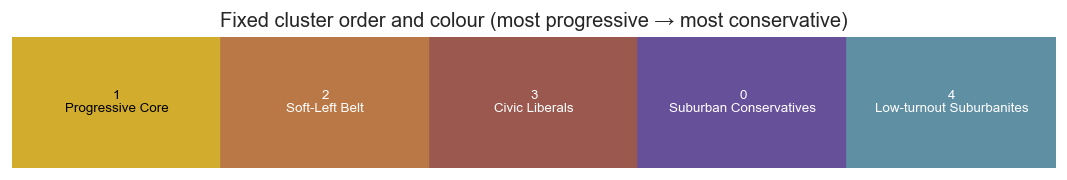

In [8]:
# ── Cluster metadata swatches, for a quick visual sanity check of the palette ─────
def _readable_text_color(hex_color):
    # Simple relative-luminance check so labels stay legible on both light and dark swatches.
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.55 else "white"

fig, ax = plt.subplots(figsize=(9, 1.6))
for pos, c in enumerate(DISPLAY_ORDER):
    color = CLUSTER_META[c]["color"]
    ax.add_patch(mpatches.Rectangle((pos, 0), 1, 1, color=color))
    ax.text(pos + 0.5, 0.5, f"{c}\n{CLUSTER_META[c]['short_label']}", ha="center", va="center",
            fontsize=8, color=_readable_text_color(color))
ax.set_xlim(0, K_CHOSEN); ax.set_ylim(0, 1)
ax.set_title("Fixed cluster order and colour (most progressive → most conservative)")
ax.axis("off")
plt.tight_layout()
plt.show()


In [9]:
# ── Build the master analysis GeoDataFrame ────────────────────────────────────────
# One row per census tract: ID, geometry, cluster ID/label, riding assignments, raw vote
# shares, city-relative deviations, within-riding deviations, and turnout. Demographic
# columns are appended once the census join is built in §6.
tracts = raw_gdf[["ct_id", "geometry"] + ALL_COLS].copy()
tracts["cluster_8f"]    = labels_8f
tracts["cluster_label"] = tracts["cluster_8f"].map(CLUSTER_LABELS)
tracts["cluster_order"] = tracts["cluster_8f"].map(lambda c: CLUSTER_META[c]["order"])
tracts = tracts.merge(riding_df, on="ct_id", how="left")

rel_named = rel_df.add_suffix("_vs_city").reset_index()
vw_named  = vw_resid_df.add_suffix("_vs_riding").reset_index()
tracts = tracts.merge(rel_named, on="ct_id", how="left").merge(vw_named, on="ct_id", how="left")

# area_km2 is used repeatedly from here on (density in §3's population table, §7's demographic
# density, §8's density scatterplot) — computed once, directly from tract geometry.
tracts["area_km2"] = tracts.to_crs(3347).geometry.area / 1e6

print(f"Master analysis table: {tracts.shape[0]} tracts x {tracts.shape[1]} columns")
print(f"CRS: {tracts.crs}  |  geometry type(s): {tracts.geom_type.unique().tolist()}")
tracts.head(3)


Master analysis table: 585 tracts x 67 columns
CRS: EPSG:4326  |  geometry type(s): ['MultiPolygon', 'Polygon']


,ct_id,geometry,mun_turnout,mun_chow,mun_bailao,mun_saunders,mun_furey,mun_matlow,mun_other,prov_turnout,...,prov_liberal_vs_riding,prov_green_vs_riding,prov_other_vs_riding,fed_turnout_vs_riding,fed_liberal_vs_riding,fed_conservative_vs_riding,fed_ndp_vs_riding,fed_green_vs_riding,fed_other_vs_riding,area_km2
0,5350001.00,"MULTIPOLYGON (((-79.30389 43.66419, -79.30397 ...",0.461942,0.516267,0.243748,0.044643,0.031523,0.054865,0.108955,0.524654,...,0.044545,-0.005595,0.004005,-0.173907,0.029923,-0.002372,-0.028962,0.000857,0.000555,7.216266
1,5350002.00,"MULTIPOLYGON (((-79.38662 43.61423, -79.38693 ...",0.665499,0.776824,0.094538,0.017861,0.021045,0.051247,0.038486,0.620391,...,-0.239209,0.019264,-0.000818,0.157846,-0.070437,-0.171688,0.240019,0.002227,-0.000121,3.564345
2,5350003.00,"MULTIPOLYGON (((-79.47039 43.63188, -79.46735 ...",0.726000,0.463646,0.286530,0.055260,0.052251,0.035852,0.106460,0.504509,...,-0.007031,0.003855,0.000626,0.443780,-0.064047,0.132029,-0.070625,0.002864,-0.000222,1.005507


## 3. Electoral Profile of Each Cluster

Now that we trust the cluster assignment and have fixed its display order and colours, we
characterise what each of the five groups actually voted for.

We start with one summary table combining cluster size, population, and a short political
signature — this is the "quick reference" row you'd reach for first when writing about any one
cluster. Getting population into this table requires the tract-level census file, so we load
just its population column here (the full census join with every demographic variable happens
in §6; re-using the same file there, not re-downloading or duplicating logic).


In [10]:
# ── Quick load: tract population, just for the summary table below ───────────────
# (§6 loads this same file again and extracts the full demographic variable set; we only need
# one column here.)
census_ct_long = pd.read_csv(CENSUS_CT_CSV)
_pop_wide = census_ct_long[census_ct_long["CHARACTERISTIC_CODE"] == "pop_2021"].set_index("GEO_NAME")["C1_COUNT_TOTAL"]
_pop_wide.index = _pop_wide.index.map(lambda x: f"{x:.2f}")   # match tracts["ct_id"] formatting

tracts["population"] = tracts["ct_id"].map(_pop_wide)
n_unmatched_pop = tracts["population"].isna().sum()
print(f"Tracts matched to a population figure: {len(tracts) - n_unmatched_pop} of {len(tracts)}")


Tracts matched to a population figure: 585 of 585


In [11]:
# ── Main cluster profile table (population + short political signature) ─────────
def short_political_signature(c):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    over, under = row.idxmax(), row.idxmin()
    turn_word = "high" if turn > 3 else ("low" if turn < -3 else "average")
    return f"{over} {row[over]:+.0f}pp / {under} {row[under]:+.0f}pp, {turn_word} turnout"

total_population = tracts["population"].sum()
profile_rows = []
for c in DISPLAY_ORDER:
    mask = tracts["cluster_8f"] == c
    profile_rows.append({
        "cluster_id": c,
        "order": CLUSTER_META[c]["order"],
        "label": CLUSTER_META[c]["label"],
        "short_label": CLUSTER_META[c]["short_label"],
        "n_tracts": int(mask.sum()),
        "pct_of_tracts": 100 * mask.mean(),
        "population": tracts.loc[mask, "population"].sum(),
        "pct_of_toronto_population": 100 * tracts.loc[mask, "population"].sum() / total_population,
        "political_signature": short_political_signature(c),
    })
main_profile_table = pd.DataFrame(profile_rows).set_index("cluster_id")
main_profile_table


,order,label,short_label,n_tracts,pct_of_tracts,population,pct_of_toronto_population,political_signature
cluster_id,,,,,,,,
1,0,Progressive Core,Progressive Core,108,18.461538,486531.0,17.411203,"prov_ndp +29pp / prov_pc -18pp, high turnout"
2,1,Soft-Left Belt,Soft-Left Belt,85,14.529915,415371.0,14.864641,"prov_ndp +13pp / prov_pc -9pp, high turnout"
3,2,Civic Liberals,Civic Liberals,77,13.162393,384610.0,13.763815,"prov_liberal +12pp / prov_ndp -16pp, high turnout"
0,3,Suburban Conservatives,Suburban Conservatives,129,22.051282,615714.0,22.034200,"prov_pc +13pp / prov_ndp -16pp, average turnout"
4,4,Low-turnout Suburbanites,Low-turnout Suburbanites,186,31.794872,892130.0,31.926140,"prov_pc +8pp / prov_ndp -8pp, low turnout"


This is the table to reach for first: five groups, ranging from 62 to 197 tracts and from
roughly 10% to a third of the city's population, each with a one-line political signature.
The rest of §3 unpacks the "political signature" column in full detail. `DISPLAY_ORDER` and
`LEAN_SCORE` (computed in §2) are used directly here and in every table/chart below — we don't
recompute them.


In [12]:
# ── Cluster-level electoral summary table ─────────────────────────────────────────
rows = []
for c in range(K_CHOSEN):
    mask = tracts["cluster_8f"] == c
    row = {"cluster": c, "label": CLUSTER_LABELS[c],
           "n_tracts": int(mask.sum()), "pct_of_tracts": 100 * mask.mean()}
    for col in ALL_COLS:
        row[f"raw_{col}"] = tracts.loc[mask, col].mean() * 100
        row[f"city_rel_{col}"] = tracts.loc[mask, f"{col}_vs_city"].mean() * 100
        row[f"riding_rel_{col}"] = tracts.loc[mask, f"{col}_vs_riding"].mean() * 100
    rows.append(row)
electoral_summary = pd.DataFrame(rows).set_index("cluster")

turnout_table = electoral_summary[[f"raw_{c}" for c in TURNOUT_COLS] + [f"city_rel_{c}" for c in TURNOUT_COLS]].round(1)
turnout_table.columns = [c.replace("raw_", "").replace("_turnout", " turnout (%)") for c in [f"raw_{c}" for c in TURNOUT_COLS]] + \
                         [c.replace("city_rel_", "").replace("_turnout", " turnout, vs. city (pp)") for c in [f"city_rel_{c}" for c in TURNOUT_COLS]]
turnout_table.insert(0, "label", electoral_summary["label"])
turnout_table.insert(1, "n_tracts", electoral_summary["n_tracts"])
turnout_table.loc[DISPLAY_ORDER]


,label,n_tracts,mun turnout (%),prov turnout (%),fed turnout (%),"mun turnout, vs. city (pp)","prov turnout, vs. city (pp)","fed turnout, vs. city (pp)"
cluster,,,,,,,,
1,Progressive Core,108,46.1,54.5,74.1,7.4,6.8,3.6
2,Soft-Left Belt,85,45.9,51.7,75.7,7.2,4.0,5.2
3,Civic Liberals,77,45.1,54.7,79.7,6.4,7.1,9.2
0,Suburban Conservatives,129,38.4,45.3,68.6,-0.4,-2.4,-1.9
4,Low-turnout Suburbanites,186,29.3,40.1,63.0,-9.4,-7.5,-7.5


### Vote-share heatmaps: city-relative deviation vs. actual level

The first heatmap is the primary read — **deviation from the citywide average**, in
percentage points, green above / red below. The second shows the same clusters' **actual**
(raw) vote shares, which matters because two clusters can share a similar *deviation* while
sitting at very different absolute levels (e.g. a modestly-below-average NDP share in an
already-NDP-heavy city is not the same as a modestly-below-average share where the party barely
registers).

Rows in both panels run most progressive (top) to most conservative (bottom), matching
`DISPLAY_ORDER` everywhere else in this notebook.


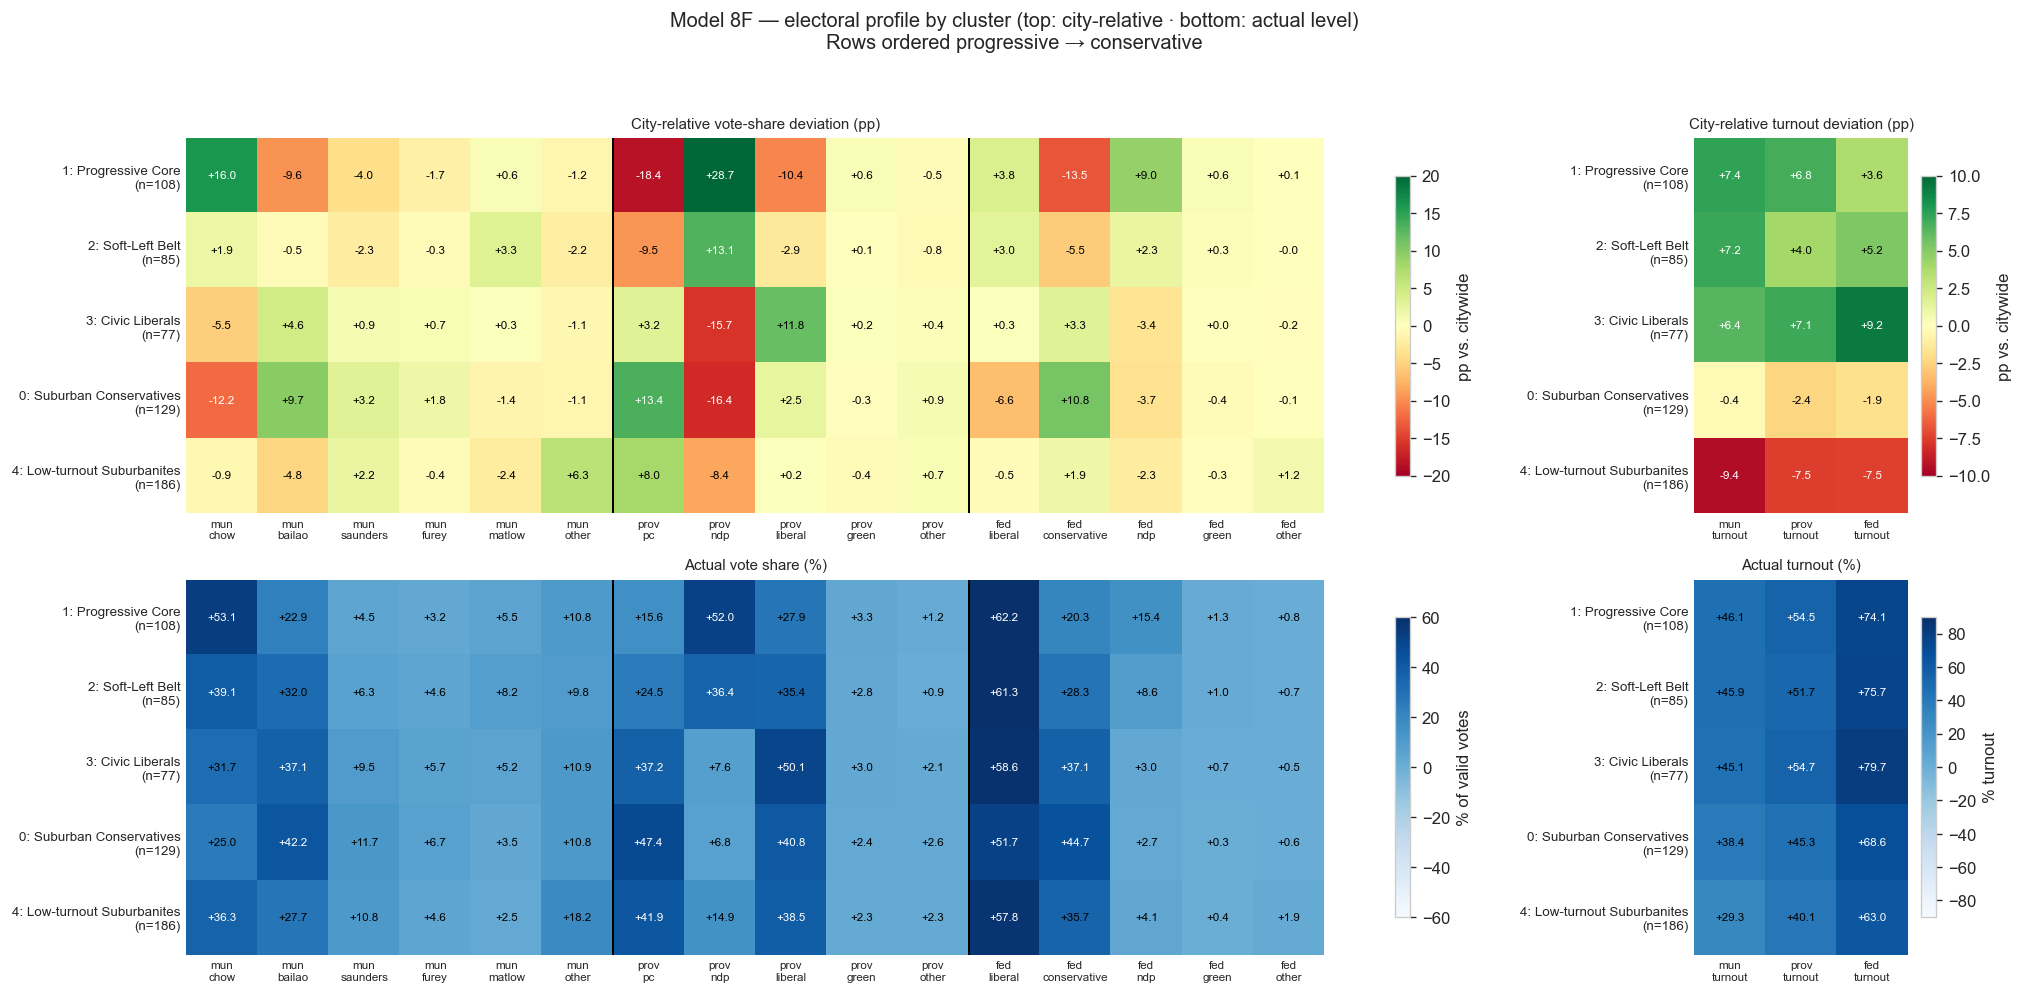

In [13]:
def draw_heatmap(ax, data, cols, title, vabs=20, cmap="RdYlGn"):
    im = ax.imshow(data[cols].values, cmap=cmap, aspect="auto", vmin=-vabs, vmax=vabs)
    for i in range(data.shape[0]):
        for j, col in enumerate(cols):
            val = data[col].iloc[i]
            txt_color = "white" if abs(val) / vabs > 0.6 else "black"
            ax.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=7, color=txt_color)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=7)
    ax.set_yticks(range(len(data))); ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(title, fontsize=9)
    # imshow heatmaps pick up the notebook-wide seaborn "whitegrid" style otherwise, which
    # draws grid lines straight through the annotated cells — turn it off explicitly here.
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return im

def cluster_row_labels(order):
    return [f"{c}: {CLUSTER_LABELS[c]}\n(n={cluster_sizes_8f[c]})" for c in order]

city_rel_profiles = check_profiles.copy()
city_rel_profiles.index = range(K_CHOSEN)

raw_profiles = electoral_summary[[f"raw_{c}" for c in ALL_COLS]].copy()
raw_profiles.columns = ALL_COLS

fig, axes = plt.subplots(2, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [len(SHARE_COLS), len(TURNOUT_COLS)]})
plot_order = DISPLAY_ORDER
im1 = draw_heatmap(axes[0, 0], city_rel_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), SHARE_COLS,
                    "City-relative vote-share deviation (pp)", vabs=20)
im2 = draw_heatmap(axes[0, 1], city_rel_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), TURNOUT_COLS,
                    "City-relative turnout deviation (pp)", vabs=10)
im3 = draw_heatmap(axes[1, 0], raw_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), SHARE_COLS,
                    "Actual vote share (%)", vabs=60, cmap="Blues")
im4 = draw_heatmap(axes[1, 1], raw_profiles.loc[plot_order].set_axis(cluster_row_labels(plot_order)), TURNOUT_COLS,
                    "Actual turnout (%)", vabs=90, cmap="Blues")
n_mun, n_prov = len(MUN_SHARE_COLS), len(PROV_SHARE_COLS)
for ax in [axes[0, 0], axes[1, 0]]:
    for x in [n_mun - 0.5, n_mun + n_prov - 0.5]:
        ax.axvline(x, color="black", lw=1.2)
fig.colorbar(im1, ax=axes[0, 0], label="pp vs. citywide", shrink=0.8)
fig.colorbar(im2, ax=axes[0, 1], label="pp vs. citywide", shrink=0.8)
fig.colorbar(im3, ax=axes[1, 0], label="% of valid votes", shrink=0.8)
fig.colorbar(im4, ax=axes[1, 1], label="% turnout", shrink=0.8)
fig.suptitle("Model 8F — electoral profile by cluster (top: city-relative · bottom: actual level)\n"
             "Rows ordered progressive → conservative", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


**Reading this.** The top-left panel is the clearest single picture of what separates the
five groups electorally: the Progressive Core and Soft-Left Belt sit on the NDP/Chow side (the
Progressive Core far more sharply), Civic Liberals stands out for the provincial Liberal vote
and a modest Bailão bump rather than a clean left-right position, and Suburban Conservatives and
Low-turnout Suburbanites sit on the PC/Conservative/Bailão side (Suburban Conservatives far more
sharply). The turnout panel tells a different story from the vote-share one: Low-turnout
Suburbanites' deficit is the largest single number there, but Civic Liberals — not one of the
progressive-leaning groups — posts the largest turnout *surplus* of the five, provincially and
federally. The bottom row shows the NDP/Chow lean isn't just about deviations: the Progressive
Core's actual NDP share (bottom-left) is genuinely high in absolute terms, not just high
relative to a low citywide baseline.


### Turnout, side by side

Turnout is one of the clearest and most consistent differentiators of the 8F solution — see
§4 below for a formal check of exactly how much it matters relative to the vote-share
variables. Here we simply look at the raw numbers, with the citywide average marked.


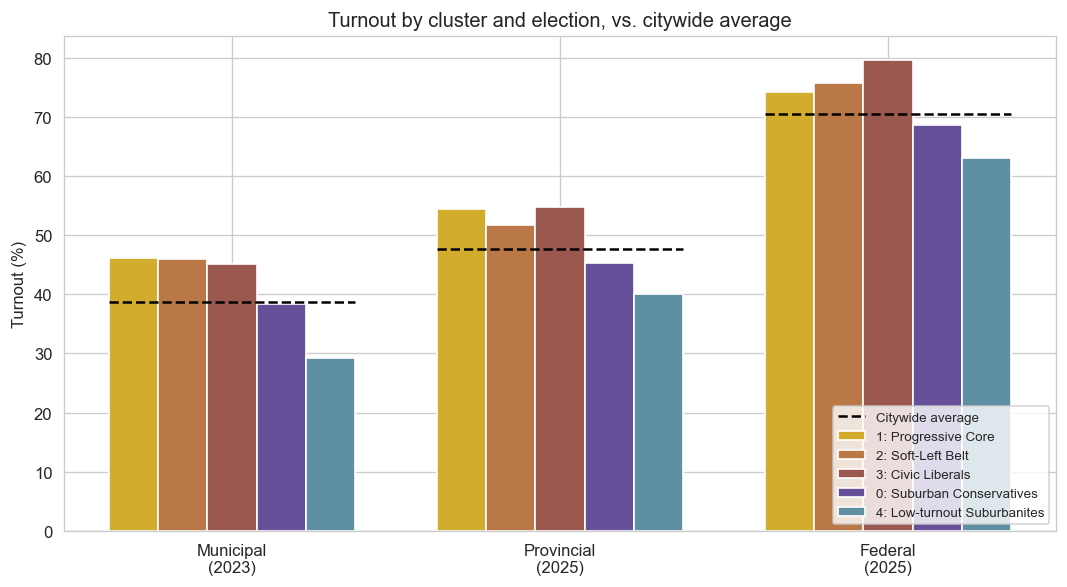

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(TURNOUT_COLS))
width = 0.15
for i, c in enumerate(DISPLAY_ORDER):
    vals = electoral_summary.loc[c, [f"raw_{t}" for t in TURNOUT_COLS]].values.astype(float)
    ax.bar(x + (i - 2) * width, vals, width, color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}")
for i, t in enumerate(TURNOUT_COLS):
    ax.hlines(citywide_s[t] * 100, x[i] - 2.5 * width, x[i] + 2.5 * width, color="black", lw=1.5, linestyle="--")
ax.plot([], [], color="black", lw=1.5, linestyle="--", label="Citywide average")
ax.set_xticks(x); ax.set_xticklabels(["Municipal\n(2023)", "Provincial\n(2025)", "Federal\n(2025)"])
ax.set_ylabel("Turnout (%)")
ax.set_title("Turnout by cluster and election, vs. citywide average")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


**Reading this.** Turnout ranks similarly in every one of the three elections: Civic Liberals
is highest or near-highest each time, the Progressive Core and Soft-Left Belt both sit
comfortably above the city average (trading 2nd and 3rd place depending on the election),
Suburban Conservatives sits just below average, and Low-turnout Suburbanites is clearly lowest
each time. That consistency — the same broad ranking holding across a municipal race, a
provincial election, and a federal election with different campaigns, candidates and turnout
drivers — is itself a signal that turnout is tracking something durable about these
neighbourhoods, not one election's idiosyncrasies.


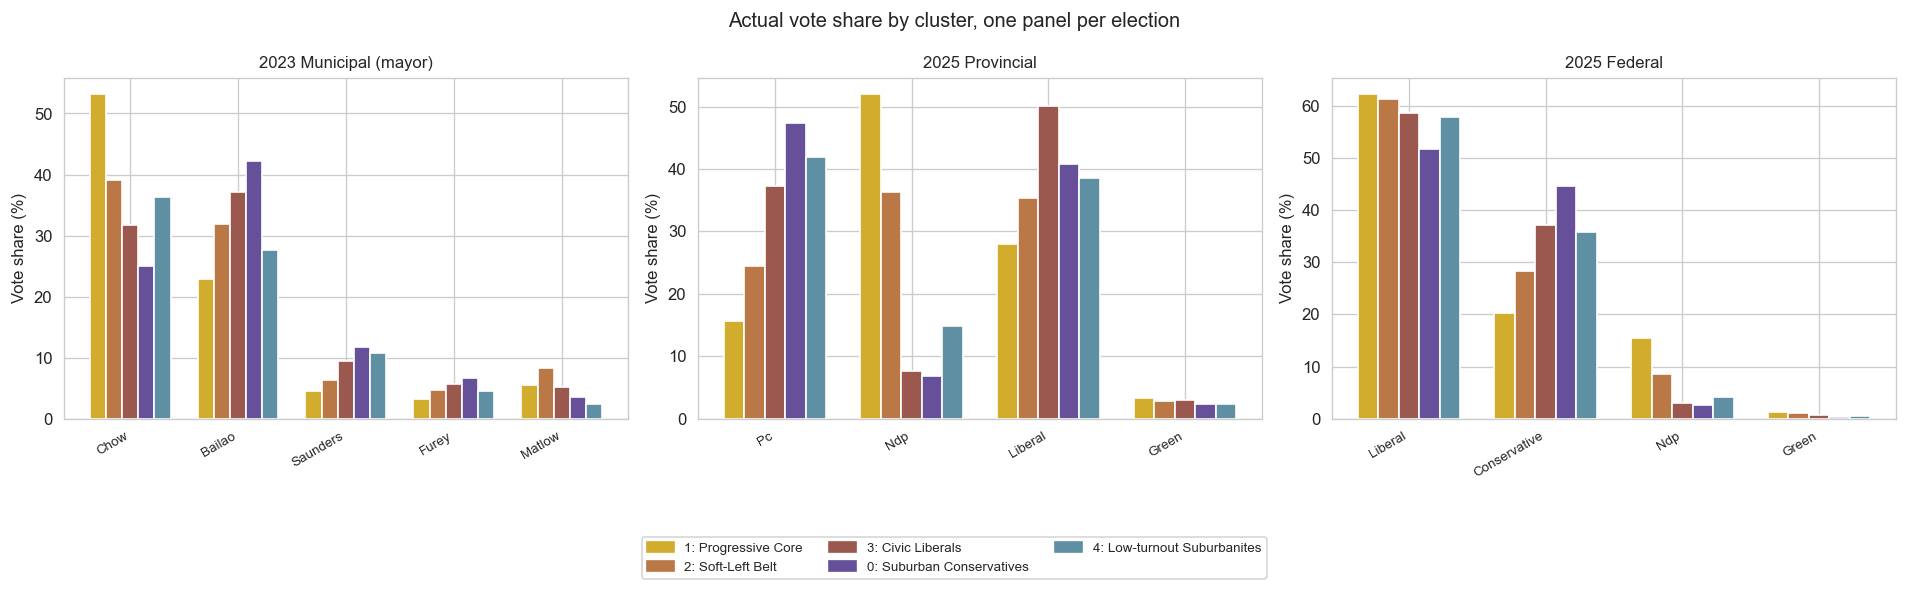

In [15]:
# ── Small multiples: vote share by party/candidate, one panel per election ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title, cols, keys) in zip(axes, [
    ("2023 Municipal (mayor)", MUN_SHARE_COLS, MUN_CANDIDATE_KEYS),
    ("2025 Provincial",        PROV_SHARE_COLS, PROV_PARTY_KEYS),
    ("2025 Federal",           FED_SHARE_COLS,  FED_PARTY_KEYS),
]):
    plot_cols = [c for c in cols if not c.endswith("_other")]
    x = np.arange(len(plot_cols))
    width = 0.15
    for i, c in enumerate(DISPLAY_ORDER):
        vals = electoral_summary.loc[c, [f"raw_{col}" for col in plot_cols]].values.astype(float)
        ax.bar(x + (i - 2) * width, vals, width, color=PALETTE_BY_ID[c])
    ax.set_xticks(x); ax.set_xticklabels([c.split("_", 1)[1].capitalize() for c in plot_cols], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Vote share (%)"); ax.set_title(title, fontsize=10)
handles = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}") for c in DISPLAY_ORDER]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=8)
fig.suptitle("Actual vote share by cluster, one panel per election", fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


**Reading this.** The municipal panel's standout is the Soft-Left Belt, where Matlow (8.2% of
the vote) most clearly outpolls Saunders (6.3%) of any group — a pattern also present, more
mildly, in the Progressive Core (5.5% vs. 4.5%) — while every PC-leaning cluster favours
Saunders over Matlow by a wide margin. The provincial and federal panels tell a related but
distinct story: the Progressive Core and Soft-Left Belt lead on NDP (and, incidentally, post the
two highest federal Liberal shares too, consistent with strategic anti-Conservative voting),
Suburban Conservatives and Low-turnout Suburbanites lead on PC/Conservative, and Civic Liberals
is the outlier — not on the federal Liberal column, where it actually trails the two NDP-leaning
groups, but on the **provincial** Liberal column specifically (50.1%, a full 9pp clear of the
next-closest group), combined with the lowest NDP share of any cluster both provincially and
federally.


In [16]:
# ── Table: top over/under-performing party or candidate per cluster (city-relative) ──
top_rows = []
for c in DISPLAY_ORDER:
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    top_rows.append({
        "cluster": c, "label": CLUSTER_LABELS[c],
        "top_overperformance": f"{row.idxmax()} ({row.max():+.1f}pp)",
        "2nd_overperformance": f"{row.nlargest(2).index[1]} ({row.nlargest(2).iloc[1]:+.1f}pp)",
        "top_underperformance": f"{row.idxmin()} ({row.min():+.1f}pp)",
        "2nd_underperformance": f"{row.nsmallest(2).index[1]} ({row.nsmallest(2).iloc[1]:+.1f}pp)",
    })
pd.DataFrame(top_rows).set_index("cluster")


,label,top_overperformance,2nd_overperformance,top_underperformance,2nd_underperformance
cluster,,,,,
1,Progressive Core,prov_ndp (+28.7pp),mun_chow (+16.0pp),prov_pc (-18.4pp),fed_conservative (-13.5pp)
2,Soft-Left Belt,prov_ndp (+13.1pp),mun_matlow (+3.3pp),prov_pc (-9.5pp),fed_conservative (-5.5pp)
3,Civic Liberals,prov_liberal (+11.8pp),mun_bailao (+4.6pp),prov_ndp (-15.7pp),mun_chow (-5.5pp)
0,Suburban Conservatives,prov_pc (+13.4pp),fed_conservative (+10.8pp),prov_ndp (-16.4pp),mun_chow (-12.2pp)
4,Low-turnout Suburbanites,prov_pc (+8.0pp),mun_other (+6.3pp),prov_ndp (-8.4pp),mun_bailao (-4.8pp)


### Actual vote levels, in plain numbers

Deviations are the right tool for finding what separates the clusters, but an article also
needs to be able to say "Cluster X actually got Y% of the vote." This table reports the raw,
actual average vote share and turnout for the headline candidates/parties in each cluster —
no citywide or riding adjustment — ordered progressive to conservative.


In [17]:
VOTE_LEVEL_COLS = {
    "mun_turnout": "2023 mayoral turnout (%)", "mun_chow": "Chow (%)", "mun_bailao": "Bailão (%)",
    "mun_matlow": "Matlow (%)", "mun_saunders": "Saunders (%)", "mun_other": "Municipal other (%)",
    "prov_turnout": "2025 provincial turnout (%)", "prov_pc": "PC (%)", "prov_ndp": "NDP, prov. (%)", "prov_liberal": "Liberal, prov. (%)",
    "fed_turnout": "2025 federal turnout (%)", "fed_liberal": "Liberal, fed. (%)", "fed_conservative": "Conservative, fed. (%)", "fed_ndp": "NDP, fed. (%)",
}
vote_level_table = electoral_summary[[f"raw_{c}" for c in VOTE_LEVEL_COLS]].round(1)
vote_level_table.columns = list(VOTE_LEVEL_COLS.values())
vote_level_table.insert(0, "label", electoral_summary["label"])
vote_level_table = vote_level_table.loc[DISPLAY_ORDER]
vote_level_table


,label,2023 mayoral turnout (%),Chow (%),Bailão (%),Matlow (%),Saunders (%),Municipal other (%),2025 provincial turnout (%),PC (%),"NDP, prov. (%)","Liberal, prov. (%)",2025 federal turnout (%),"Liberal, fed. (%)","Conservative, fed. (%)","NDP, fed. (%)"
cluster,,,,,,,,,,,,,,,
1,Progressive Core,46.1,53.1,22.9,5.5,4.5,10.8,54.5,15.6,52.0,27.9,74.1,62.2,20.3,15.4
2,Soft-Left Belt,45.9,39.1,32.0,8.2,6.3,9.8,51.7,24.5,36.4,35.4,75.7,61.3,28.3,8.6
3,Civic Liberals,45.1,31.7,37.1,5.2,9.5,10.9,54.7,37.2,7.6,50.1,79.7,58.6,37.1,3.0
0,Suburban Conservatives,38.4,25.0,42.2,3.5,11.7,10.8,45.3,47.4,6.8,40.8,68.6,51.7,44.7,2.7
4,Low-turnout Suburbanites,29.3,36.3,27.7,2.5,10.8,18.2,40.1,41.9,14.9,38.5,63.0,57.8,35.7,4.1


In [18]:
# ── Plain-language summary of the table above, generated from the actual numbers ──
def cluster_line(c):
    # Deliberately not .lower()'d: several short_labels contain acronyms (NDP, PC) that
    # would be mangled by naive lowercasing (e.g. "anti-NDP" -> "anti-ndp").
    return f"the {CLUSTER_META[c]['short_label']} (Cluster {c})"

highest_chow   = electoral_summary["raw_mun_chow"].idxmax()
highest_pc     = electoral_summary["raw_prov_pc"].idxmax()
highest_con    = electoral_summary["raw_fed_conservative"].idxmax()
highest_lib_p  = electoral_summary["raw_prov_liberal"].idxmax()
lowest_turnout = electoral_summary[[f"raw_{t}" for t in TURNOUT_COLS]].mean(axis=1).idxmin()

summary_md = f'''
- **Highest Chow share:** {cluster_line(highest_chow)}, at {electoral_summary.loc[highest_chow, "raw_mun_chow"]:.0f}% of the 2023 mayoral vote.
- **Highest provincial PC share:** {cluster_line(highest_pc)}, at {electoral_summary.loc[highest_pc, "raw_prov_pc"]:.0f}%.
- **Highest federal Conservative share:** {cluster_line(highest_con)}, at {electoral_summary.loc[highest_con, "raw_fed_conservative"]:.0f}%.
- **Highest provincial Liberal share:** {cluster_line(highest_lib_p)}, at {electoral_summary.loc[highest_lib_p, "raw_prov_liberal"]:.0f}% — this is the clearest single-number signature of Civic Liberals.
- **Lowest turnout, averaged across the three elections:** {cluster_line(lowest_turnout)}, at {electoral_summary.loc[lowest_turnout, [f"raw_{t}" for t in TURNOUT_COLS]].mean():.0f}% average turnout.

These are descriptions of where each number happens to be highest or lowest among the five
groups — not a claim about why, and not a statement about how any individual voted.
'''
display(Markdown(summary_md))



- **Highest Chow share:** the Progressive Core (Cluster 1), at 53% of the 2023 mayoral vote.
- **Highest provincial PC share:** the Suburban Conservatives (Cluster 0), at 47%.
- **Highest federal Conservative share:** the Suburban Conservatives (Cluster 0), at 45%.
- **Highest provincial Liberal share:** the Civic Liberals (Cluster 3), at 50% — this is the clearest single-number signature of Civic Liberals.
- **Lowest turnout, averaged across the three elections:** the Low-turnout Suburbanites (Cluster 4), at 44% average turnout.

These are descriptions of where each number happens to be highest or lowest among the five
groups — not a claim about why, and not a statement about how any individual voted.


## 4. What Splits the City?

The profile heatmap already suggests answers, but we can be more systematic: for each of the
18 underlying features (turnout + vote share x 3 elections), how much of its variance across
all 585 tracts is *between* the five clusters, versus *within* them? A feature with a high
between/total ratio is one the clustering leans on heavily to tell groups apart; a feature with
a low ratio varies just as much within clusters as between them, and isn't doing much
differentiating work.

This is a description of the fitted clustering solution, not a causal or predictive claim.


In [19]:
def between_within_variance(df_vals, labels, k):
    # Between-cluster variance share for each column: SS_between / SS_total.
    grand_mean = df_vals.mean(axis=0)
    ss_total = ((df_vals - grand_mean) ** 2).sum(axis=0)
    ss_between = np.zeros(df_vals.shape[1])
    for c in range(k):
        mask = labels == c
        if mask.sum() == 0:
            continue
        cluster_mean = df_vals[mask].mean(axis=0)
        ss_between += mask.sum() * (cluster_mean - grand_mean) ** 2
    return np.divide(ss_between, ss_total, out=np.zeros_like(ss_total), where=ss_total > 0)

# Diagnostics run on the same block-weighted, blended feature space the k-means actually saw,
# so "most differentiating" reflects what the model used, not the raw unweighted vote shares.
bw_ratio = between_within_variance(X_blend_8f, labels_8f, K_CHOSEN)
blended_col_names = [f"{c}_city" for c in ALL_COLS] + [f"{c}_riding" for c in ALL_COLS]
diff_table = pd.DataFrame({"feature": blended_col_names, "between_var_share": bw_ratio}) \
    .sort_values("between_var_share", ascending=False).reset_index(drop=True)

# Same diagnostic on the raw (unweighted) city-relative shares, for an interpretable pp range.
raw_range = pd.Series(
    {col: check_profiles[col].max() - check_profiles[col].min() for col in ALL_COLS},
    name="max_minus_min_pp",
)

print("Top 10 most differentiating features (share of variance that is between-cluster):")
diff_table.head(10)


Top 10 most differentiating features (share of variance that is between-cluster):


,feature,between_var_share
0,prov_ndp_city,0.729916
1,prov_pc_city,0.674741
2,mun_saunders_city,0.646374
3,fed_conservative_city,0.642406
4,mun_chow_city,0.641109
5,fed_ndp_city,0.613858
6,mun_bailao_city,0.527302
7,mun_turnout_city,0.476713
8,mun_furey_city,0.446124
9,prov_turnout_city,0.433118


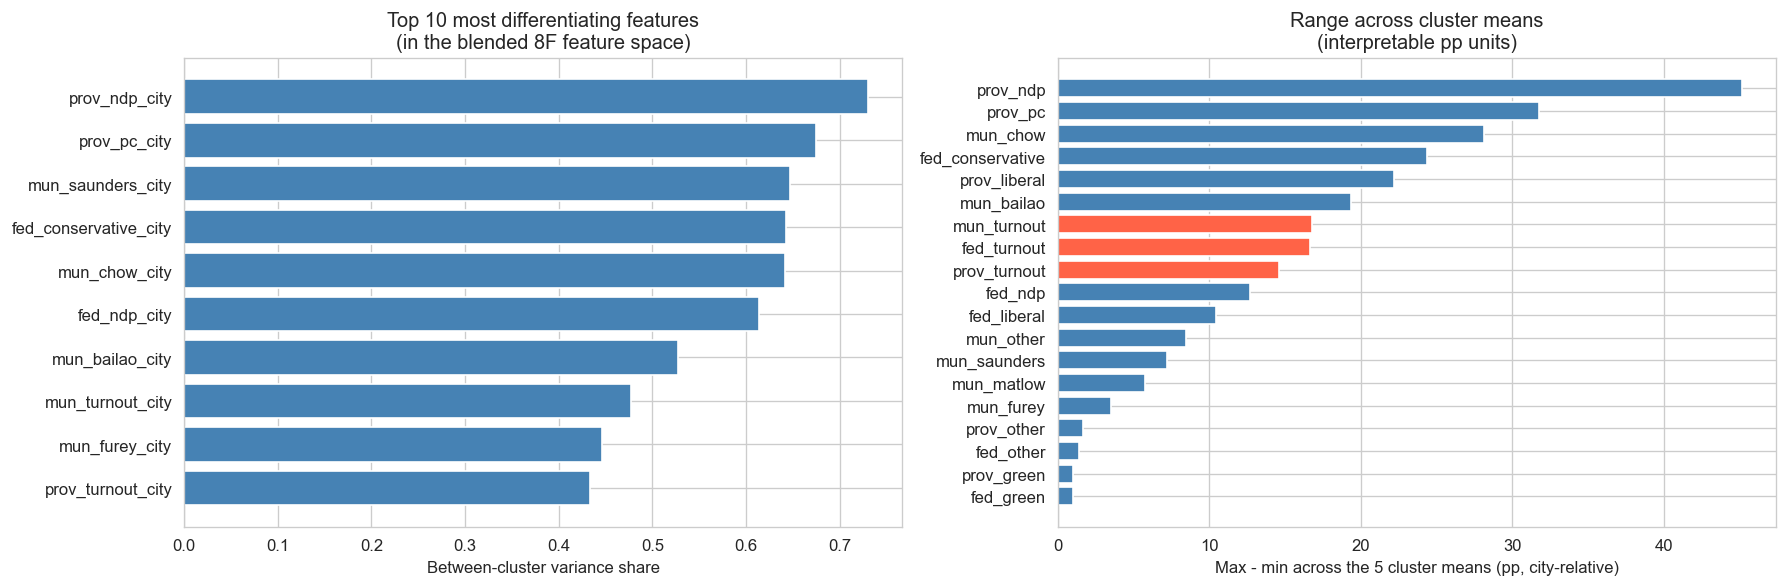

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10 = diff_table.head(10)
axes[0].barh(top10["feature"][::-1], top10["between_var_share"][::-1], color="steelblue")
axes[0].set_xlabel("Between-cluster variance share")
axes[0].set_title("Top 10 most differentiating features\n(in the blended 8F feature space)")

range_sorted = raw_range.sort_values(ascending=False)
colors = ["tomato" if "turnout" in c else "steelblue" for c in range_sorted.index]
axes[1].barh(range_sorted.index[::-1], range_sorted.values[::-1], color=colors[::-1])
axes[1].set_xlabel("Max - min across the 5 cluster means (pp, city-relative)")
axes[1].set_title("Range across cluster means\n(interpretable pp units)")
plt.tight_layout()
plt.show()


**Reading this.** Provincial NDP and PC vote share dominate the "most differentiating" list on
both measures — consistent with §3, where the sharpest cross-cluster contrasts were on those
two columns. Turnout variables (tomato bars, right panel) show up mid-table rather than at the
very top: they matter — Low-turnout Suburbanites' deficit and Civic Liberals' surplus are both
real and consistent (§3) — but the single biggest range-in-pp terms belongs to partisan vote
share, not turnout. In other words: **the 8F clusters are primarily a partisan-lean split with a
turnout dimension layered on top, not a turnout-first split with partisanship as a footnote.**


### Is there a second axis that captures something genuinely different?

PC2 explains almost as much variance as PC1 (18.0% vs. 21.6%), which makes it the obvious
second axis to plot — but explained variance alone doesn't say whether a component actually
tracks the *cluster* structure or just some other source of variation in the data. We check
this directly: reusing the same between/within-cluster variance diagnostic from earlier in this
section, but applied to PC scores instead of raw features — for each of the first six
components, what share of its variance sits *between* the five clusters?


component  pct_of_total_variance  between_cluster_variance_share
      PC1                 21.366                           0.701
      PC2                 17.768                           0.169
      PC3                 11.401                           0.496
      PC4                  8.135                           0.419
      PC5                  6.019                           0.246
      PC6                  4.492                           0.063


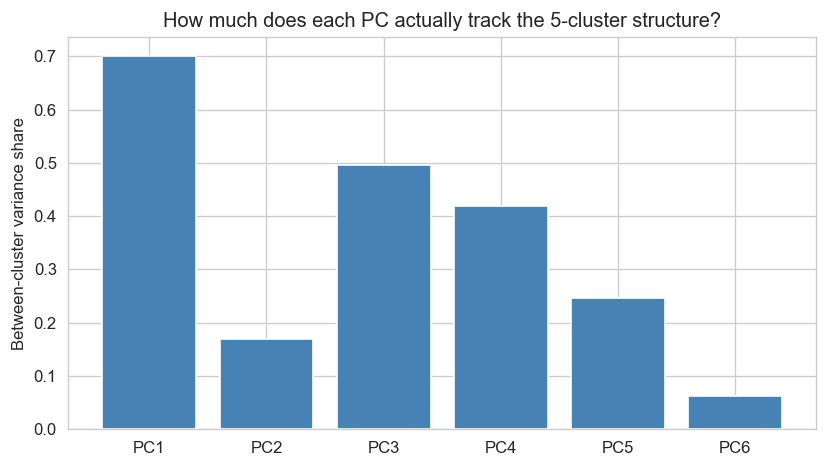

In [21]:
pca_scan = PCA(n_components=6, random_state=RANDOM_STATE).fit(X_blend_8f)
X_pc_scan = pca_scan.transform(X_blend_8f)
pc_bw_share = between_within_variance(X_pc_scan, labels_8f, K_CHOSEN)

pc_scan_table = pd.DataFrame({
    "component": [f"PC{i + 1}" for i in range(6)],
    "pct_of_total_variance": pca_scan.explained_variance_ratio_ * 100,
    "between_cluster_variance_share": pc_bw_share,
}).round(3)
print(pc_scan_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pc_scan_table["component"], pc_scan_table["between_cluster_variance_share"], color="steelblue")
ax.set_ylabel("Between-cluster variance share")
ax.set_title("How much does each PC actually track the 5-cluster structure?")
plt.tight_layout()
plt.show()


**Reading this.** PC2 carries the second-most variance overall (18.0%) but tracks the actual
5-cluster split the *least* of the first six components (between-cluster share around 0.22) —
most of what PC2 captures is variation *within* clusters, dominated by "other"/minor-party
vote share (see its loadings below), which reads more like interpolation noise than a distinct
political trend. **PC3 does much better** (between-cluster share around 0.52, more than double
PC2's) despite explaining less total variance (11.1%) — and, unlike PC2, its loadings describe
a genuinely different trend from PC1: turnout (city-relative, negative loading) blended with
within-riding NDP/Chow lean (positive loading), rather than another cut of the same citywide
left-right divide. We use **PC3** as the y-axis below instead of PC2 for exactly that reason.


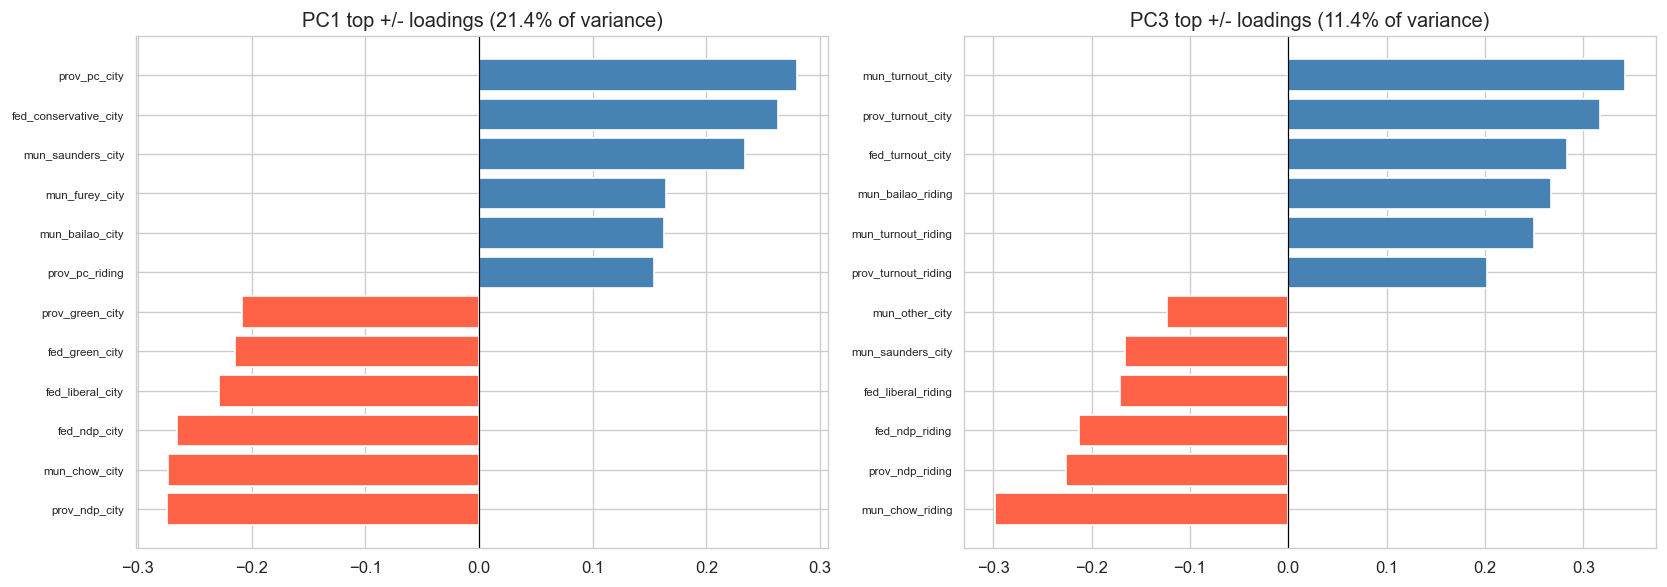

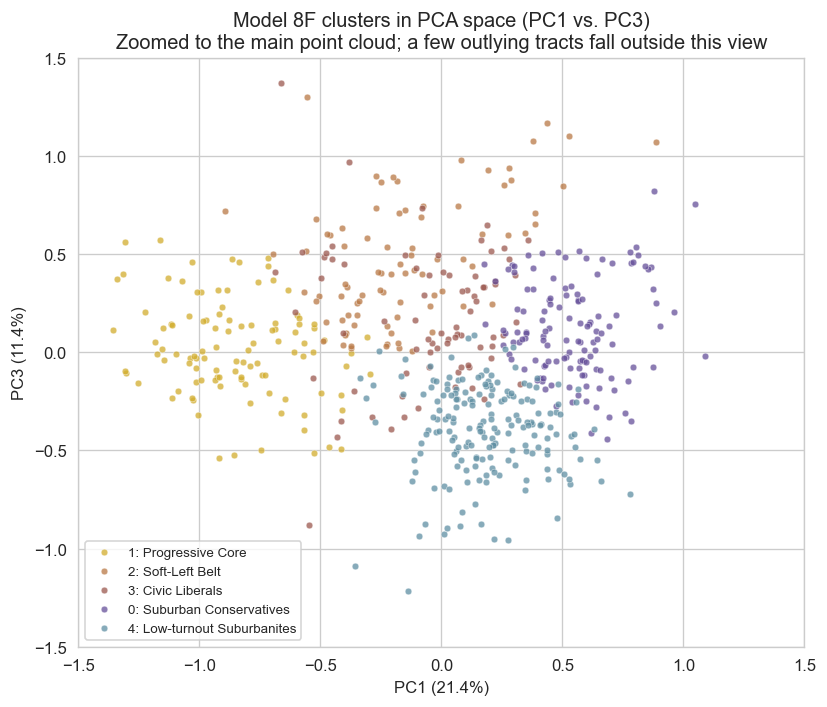

In [22]:
# ── PCA loadings and scatter for the blended 8F feature space ────────────────────
# y-axis is PC3, not PC2 — see the diagnostic above: PC3 tracks the cluster structure far more
# than PC2 does, and represents a genuinely different trend (turnout + within-riding lean)
# rather than another view of PC1's citywide left-right divide.
pca_8f = PCA(n_components=min(6, X_blend_8f.shape[1]), random_state=RANDOM_STATE).fit(X_blend_8f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc_idx in zip(axes, [0, 2]):
    loadings = pd.Series(pca_8f.components_[pc_idx], index=blended_col_names).sort_values()
    top_loadings = pd.concat([loadings.head(6), loadings.tail(6)])
    colors = ["tomato" if v < 0 else "steelblue" for v in top_loadings]
    ax.barh(range(len(top_loadings)), top_loadings.values, color=colors)
    ax.set_yticks(range(len(top_loadings))); ax.set_yticklabels(top_loadings.index, fontsize=7)
    ax.axvline(0, color="black", lw=0.7)
    ax.set_title(f"PC{pc_idx + 1} top +/- loadings ({pca_8f.explained_variance_ratio_[pc_idx] * 100:.1f}% of variance)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
X_pca_plot = pca_8f.transform(X_blend_8f)
for c in DISPLAY_ORDER:
    mask = labels_8f == c
    ax.scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 2], color=PALETTE_BY_ID[c], s=16, alpha=0.75,
               edgecolors="white", linewidths=0.3, label=f"{c}: {CLUSTER_LABELS[c]}")
ax.set_xlabel(f"PC1 ({pca_8f.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC3 ({pca_8f.explained_variance_ratio_[2] * 100:.1f}%)")
# Zoomed to where the vast majority of tracts sit, at a scale consistent with the earlier
# PC1/PC2 view; a handful of outlying tracts fall outside this window and are deliberately
# cropped out of view so the main cluster separation reads clearly.
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title("Model 8F clusters in PCA space (PC1 vs. PC3)\nZoomed to the main point cloud; a few outlying tracts fall outside this view")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading this.** PC1 is still essentially the NDP/Chow ↔ PC/Bailão axis (dominated by
`prov_ndp_city`, `prov_pc_city`, `mun_chow_city`, `mun_bailao_city`) — the same axis that
separates the progressive-leaning clusters from the PC/conservative-leaning clusters in every
chart so far. PC3 is a different mix: its largest loadings are **turnout** (`mun_turnout_city`,
`prov_turnout_city`, `fed_turnout_city`, all negative) together with **within-riding** NDP/Chow
lean (`prov_ndp_riding`, `fed_ndp_riding`, `mun_chow_riding`, all positive) — turnout and
riding-relative lean, not citywide partisanship. On this axis, Low-turnout Suburbanites
sits at the positive extreme (low turnout pulls its score up, since turnout loads
negatively) and the Soft-Left Belt sits at the negative extreme, with the other three
clusters landing in between rather than being cleanly separated. That's a real, different
pattern from PC1 — direct visual confirmation that turnout is a genuinely separate dimension in
this model, not just a minor variation on the left-right split (consistent with the
between/within diagnostic earlier in this section) — though PC3 spreads the clusters out less
cleanly than PC1 does, which is exactly what its lower between-cluster variance share predicts.


### In plain terms: what does each axis actually ask?

- **PC1 asks: "Compared to Toronto as a whole, does this place lean more NDP/Chow, or more
  PC/Conservative/Bailão?"** It's a single citywide yardstick — one number that says whether a
  tract sits to the left or right of the city's overall centre of gravity, full stop. This is
  the question most election coverage already asks, just usually one race at a time.
- **PC3 asks two different questions at once, neither of which is "left or right":**
  1. *"Do people here turn out to vote more or less than elsewhere?"* — an engagement question,
     not a partisan one. A tract can score high on this for being disengaged regardless of who
     it would otherwise support.
  2. *"Compared to its own riding-mates, not the whole city, is this place unusually
     NDP/Chow-leaning?"* — a local, relative question. A tract can be modest by citywide
     standards (near-average on PC1) while still standing out sharply from its immediate
     political neighbours.

A useful shorthand: **PC1 is about identity — where a place sits on the map of Toronto's
politics. PC3 is about behaviour and context — how much a place shows up to vote, and how it
compares to the company it keeps (its own riding), rather than to the city at large.** Those
are genuinely different questions, which is exactly why the two axes pull the five clusters
apart in different ways rather than just repeating the same left-right split at two zoom levels.


### A t-SNE view, for reference only

t-SNE is a non-linear layout, not a distance-preserving projection like PCA — it is **not**
used anywhere in the 8F pipeline (block-weighting, PCA, and k-means are the only steps that
actually produce the cluster labels). We include it here purely as an alternative picture of
how separated the five groups look, run on the same block-weighted, 50/50-blended feature space
(`X_blend_8f`) the k-means step above was fit on.


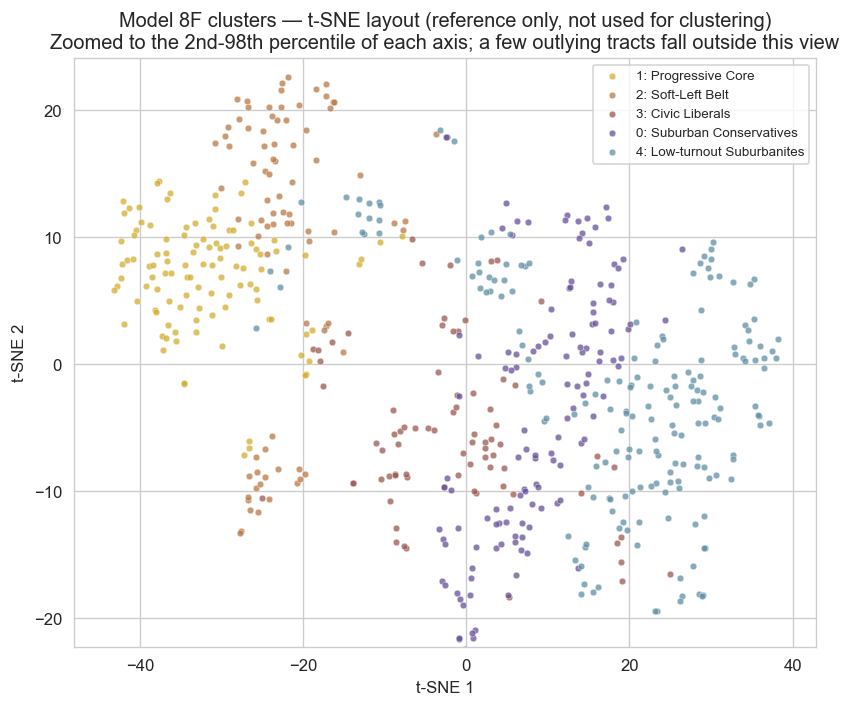

In [23]:
# ── t-SNE, shown for reference only — NOT part of the 8F clustering pipeline ─────
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
X_tsne = tsne.fit_transform(X_blend_8f)

# t-SNE coordinates have no inherent unit or scale (unlike PCA's explained-variance axes), so
# "zoom to omit outliers" is done here by clipping to the 2nd-98th percentile of each axis with
# a little padding, rather than reusing the PCA plot's fixed -1.5..1.5 / -1..1.5 window, which
# would be an arbitrary crop on a different coordinate system.
x_lo, x_hi = np.percentile(X_tsne[:, 0], [2, 98])
y_lo, y_hi = np.percentile(X_tsne[:, 1], [2, 98])
x_pad, y_pad = 0.1 * (x_hi - x_lo), 0.1 * (y_hi - y_lo)

fig, ax = plt.subplots(figsize=(7, 6))
for c in DISPLAY_ORDER:
    mask = labels_8f == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=PALETTE_BY_ID[c], s=16, alpha=0.75,
               edgecolors="white", linewidths=0.3, label=f"{c}: {CLUSTER_LABELS[c]}")
ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.set_title("Model 8F clusters — t-SNE layout (reference only, not used for clustering)\n"
             "Zoomed to the 2nd-98th percentile of each axis; a few outlying tracts fall outside this view")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading this.** The same five colours separate out here too, which is a reassuring sanity
check, but read this plot as illustrative rather than analytical — t-SNE distances and
densities are not meaningful the way PCA's are, and nothing about this layout influenced the
cluster assignment.


In [24]:
# ── Cluster centroid distances in PCA space ───────────────────────────────────────
centroids_pca = np.array([X_pca_8f[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)])
dist_matrix = pd.DataFrame(
    np.linalg.norm(centroids_pca[:, None, :] - centroids_pca[None, :, :], axis=-1),
    index=[f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)],
    columns=[f"{c}" for c in range(K_CHOSEN)],
).loc[[f"{c}: {CLUSTER_LABELS[c]}" for c in DISPLAY_ORDER], [str(c) for c in DISPLAY_ORDER]]
print("Pairwise centroid distances in PCA space (larger = more distinct; rows/cols ordered progressive -> conservative):")
dist_matrix.round(2)


Pairwise centroid distances in PCA space (larger = more distinct; rows/cols ordered progressive -> conservative):


,1,2,3,0,4
1: Progressive Core,0.00,1.04,1.19,1.54,1.20
2: Soft-Left Belt,1.04,0.00,0.93,0.99,1.03
3: Civic Liberals,1.19,0.93,0.00,0.87,0.89
0: Suburban Conservatives,1.54,0.99,0.87,0.00,0.78
4: Low-turnout Suburbanites,1.20,1.03,0.89,0.78,0.00


**On what the centroid distances show:**

- **The Progressive Core is the most isolated cluster in the model** — it sits at a larger
  distance from every other cluster (1.04-1.54) than any other pair of clusters sits from each
  other, including a full 1.54 from Suburban Conservatives, the largest single value in the
  whole matrix. That's the clearest sign of a genuine left-right pole rather than a group that
  shades gradually into its neighbours.
- **Suburban Conservatives and Low-turnout Suburbanites are the two closest centroids in the
  table** (0.78, the smallest distance anywhere in the matrix) — both lean PC/Conservative, and
  are separated mainly by how far below the citywide turnout average Low-turnout Suburbanites
  sits (§3's turnout chart shows this holding across all three elections). That's a real,
  consistent distinction, but it's the softest of the model's five boundaries — worth flagging
  plainly in any write-up rather than presenting all five groups as equally sharply separated.
  (This matches §10's boundary-tract table below, which is dominated by exactly this pair.)
- **Civic Liberals sits at a roughly similar, moderate distance from all four other clusters**
  (0.87-1.19) rather than reading as an extreme pole or a near-duplicate of any one neighbour —
  consistent with it being defined by a specific, cross-cutting profile (provincial Liberal
  strength and high turnout) rather than a weaker version of the main left-right split.


## 5. Spatial Concentration and Geography

Where does each group actually live? We start with the plain cluster map, then the same map
with **ward boundaries** overlaid (using the same dissolved ward polygons `ward_gdf` built for
riding assignment in §2 — no separate ward-boundary file is needed), then look at how clusters
distribute across wards and ridings — both "what share of ward X is cluster Y" and "what share
of cluster Y sits in ward X" — since those answer different questions (is a ward internally
consistent? vs. is a cluster geographically concentrated or scattered across many ridings?).


In [25]:
# ── Ward polygons, for the "with ward boundaries" map just below ─────────────────
# Dissolved from the 2023 polling-subdivision boundaries (the same source and method 02 used to
# assign each tract to a ward) -- needed here only as background geometry for one plot; ward
# *assignment* for each tract already came from the loaded Model 8F file (`riding_df` above).
subdiv_gdf = gpd.read_file(SUBDIVISIONS_GEOJSON)
subdiv_gdf["ward"] = subdiv_gdf["AREA_LONG_CODE"].str[:2].astype(str)
ward_gdf = subdiv_gdf.dissolve(by="ward")

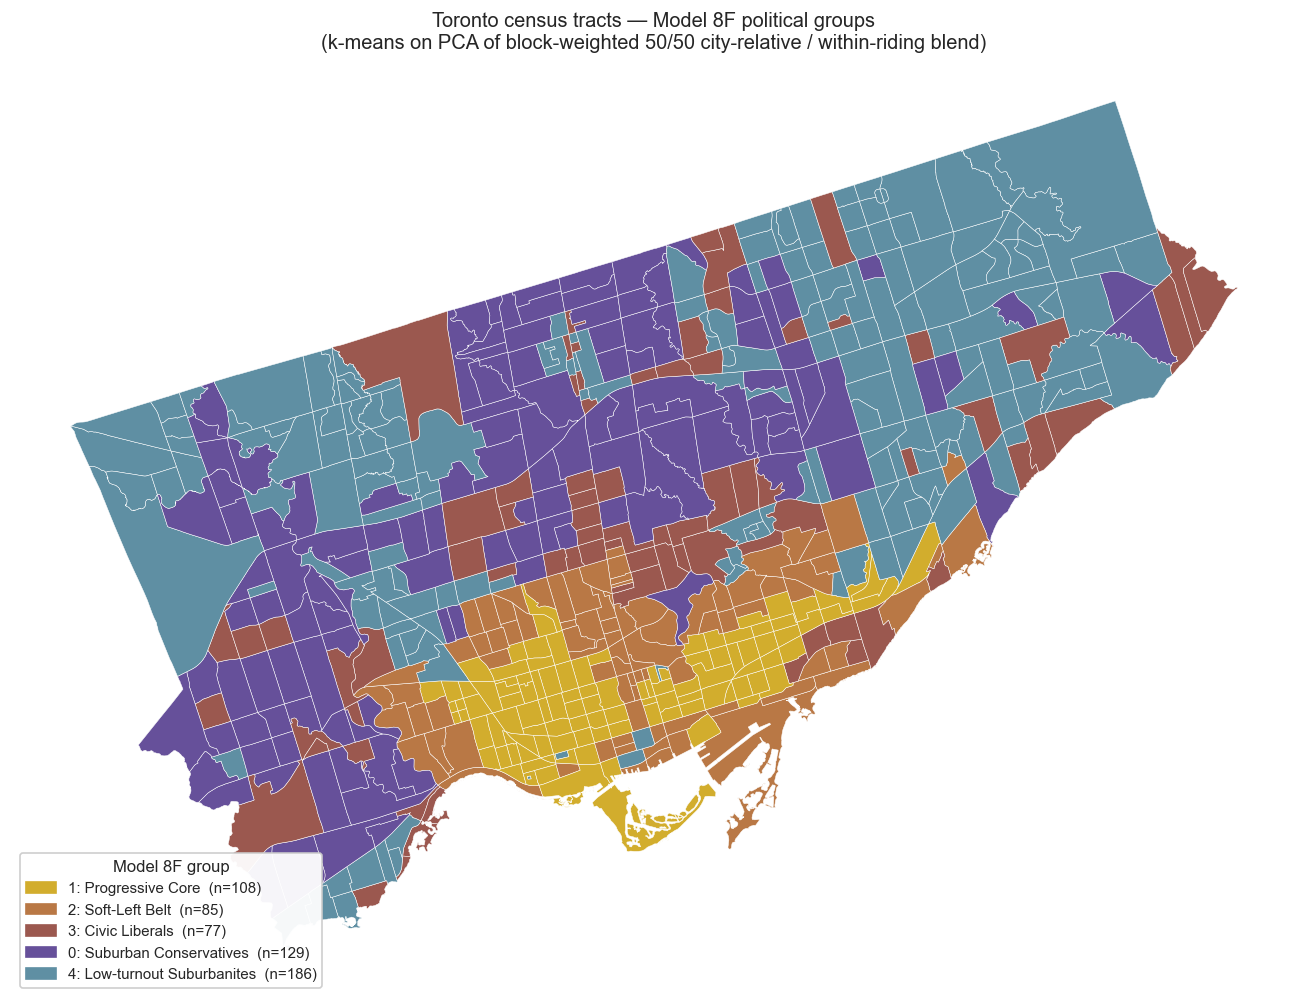

In [26]:
def plot_cluster_map(ax, show_wards=False):
    cmap_8f = mcolors.ListedColormap([PALETTE_BY_ID[c] for c in range(K_CHOSEN)])
    tracts.plot(column="cluster_8f", ax=ax, categorical=True, cmap=cmap_8f, edgecolor="white", linewidth=0.3, legend=False)
    if show_wards:
        ward_gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=1.1)
    patches = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}  (n={cluster_sizes_8f[c]})") for c in DISPLAY_ORDER]
    ax.legend(handles=patches, loc="lower left", fontsize=9, framealpha=0.95, title="Model 8F group")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 12))
plot_cluster_map(ax, show_wards=False)
ax.set_title("Toronto census tracts — Model 8F political groups\n"
             "(k-means on PCA of block-weighted 50/50 city-relative / within-riding blend)", fontsize=12)
plt.tight_layout()
plt.show()


**Reading this.** The map is not a clean "downtown left, suburbs right" picture. The
Progressive Core and Soft-Left Belt do sit where a conventional story would expect them — the
old City of Toronto, hugging the downtown core and the lake east toward the Beaches. But
Suburban Conservatives is not purely an outer-suburban story: alongside a large block across
Etobicoke, it also forms a dense, contiguous mass across a central-north swath (roughly the
former City of North York / midtown corridor) — a conservative-leaning pattern sitting well
inside the old inner suburbs, not out at the city's edge. Low-turnout Suburbanites is the one
that actually reads as classically suburban/exurban: it dominates the far northwest, the far
northeast (Scarborough), and fills in much of the space between the other groups. Civic Liberals
shows up as smaller patches scattered across several separate, mostly affluent pockets — the
Etobicoke lakeshore, a central corridor around Don Valley and Eglinton-Lawrence, and the far
east end — rather than a single bloc, consistent with a locally-anchored rather than broadly
geographic identity.


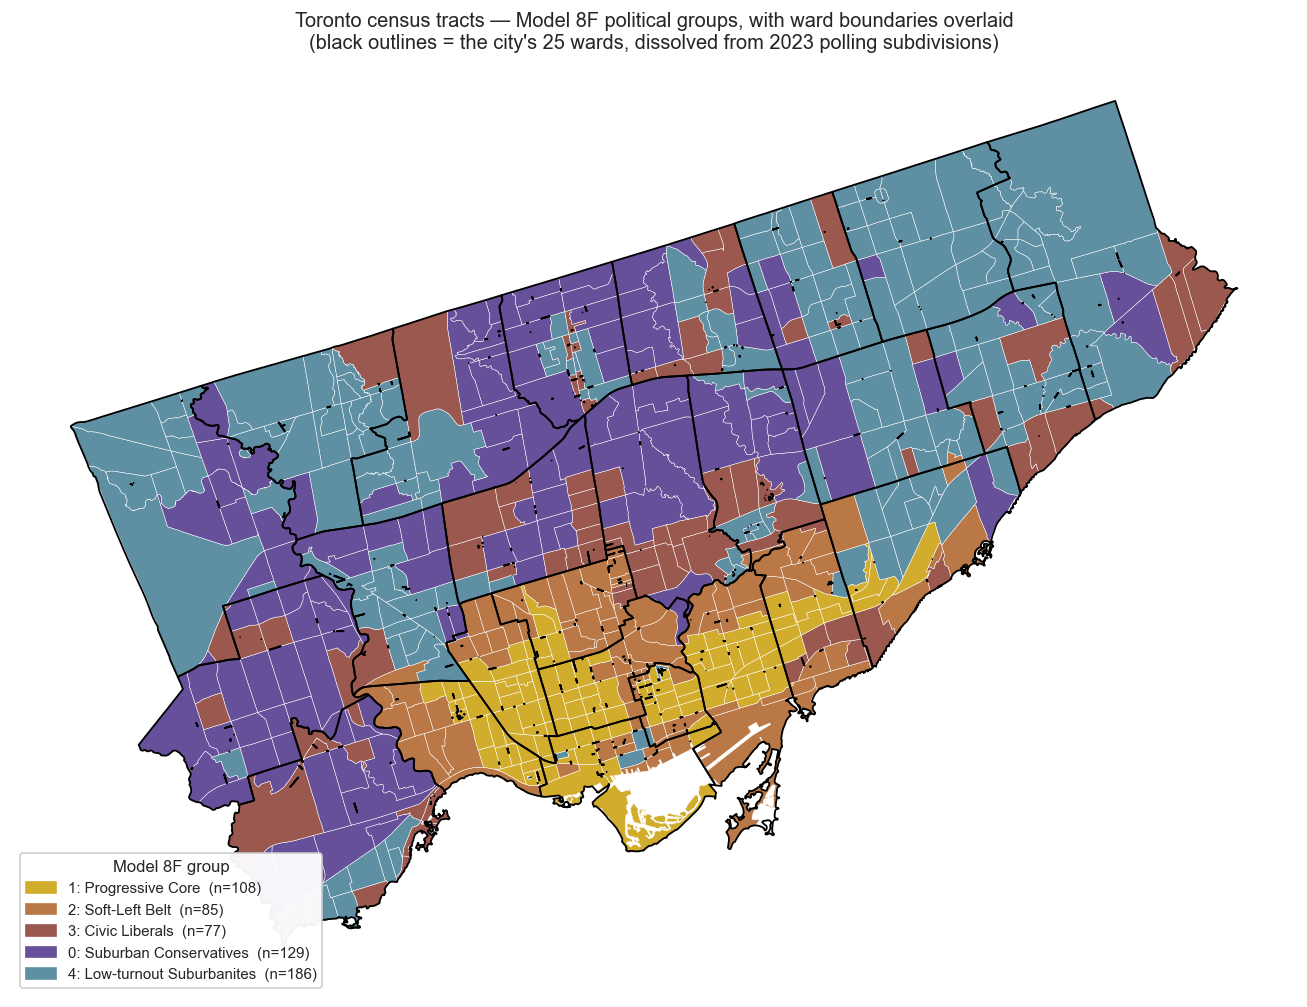

In [27]:
fig, ax = plt.subplots(figsize=(11, 12))
plot_cluster_map(ax, show_wards=True)
ax.set_title("Toronto census tracts — Model 8F political groups, with ward boundaries overlaid\n"
             "(black outlines = the city's 25 wards, dissolved from 2023 polling subdivisions)", fontsize=12)
plt.tight_layout()
plt.show()


**Reading this.** Overlaying ward boundaries makes it easy to see, at a glance, which wards a
given cluster's tracts fall inside — useful for cross-referencing against the stacked bar chart
right below, and for a reader who knows Toronto's ward map better than its census tracts. A few
wards visibly hold almost entirely one colour (e.g. the wards anchored in the progressive
core's downtown band); most others clearly mix two or three colours within their boundary — the
stacked bar chart quantifies exactly how mixed each of the 25 wards is.


In [28]:
# ── Cluster composition by ward / provincial riding / federal riding ─────────────
def geography_tables(tracts, geo_col, geo_label):
    ct = pd.crosstab(tracts[geo_col], tracts["cluster_8f"])
    ct = ct[DISPLAY_ORDER]
    ct.columns = [f"{c}: {CLUSTER_LABELS[c]}" for c in ct.columns]
    share_within_geo = ct.div(ct.sum(axis=1), axis=0) * 100      # "what % of this geography is cluster c"
    share_of_cluster = ct.div(ct.sum(axis=0), axis=1) * 100      # "what % of cluster c sits in this geography"
    return ct, share_within_geo, share_of_cluster

ward_counts, ward_share_within, ward_share_of_cluster = geography_tables(tracts, "ward_label", "ward")
prov_counts, prov_share_within, prov_share_of_cluster = geography_tables(tracts, "prov_riding", "provincial riding")
fed_counts,  fed_share_within,  fed_share_of_cluster  = geography_tables(tracts, "fed_riding",  "federal riding")

print(f"Wards: {tracts['ward_label'].nunique()}  |  Provincial ridings: {tracts['prov_riding'].nunique()}  |  "
      f"Federal ridings: {tracts['fed_riding'].nunique()}")
ward_counts


Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


,1: Progressive Core,2: Soft-Left Belt,3: Civic Liberals,0: Suburban Conservatives,4: Low-turnout Suburbanites
ward_label,,,,,
Ward 1,0,0,1,9,12
Ward 10,11,8,0,0,3
Ward 11,14,10,0,0,0
Ward 12,5,18,1,0,0
Ward 13,12,7,0,0,1
Ward 14,19,9,0,0,0
Ward 15,0,0,10,10,3
Ward 16,0,0,5,8,7
Ward 17,0,0,7,10,7


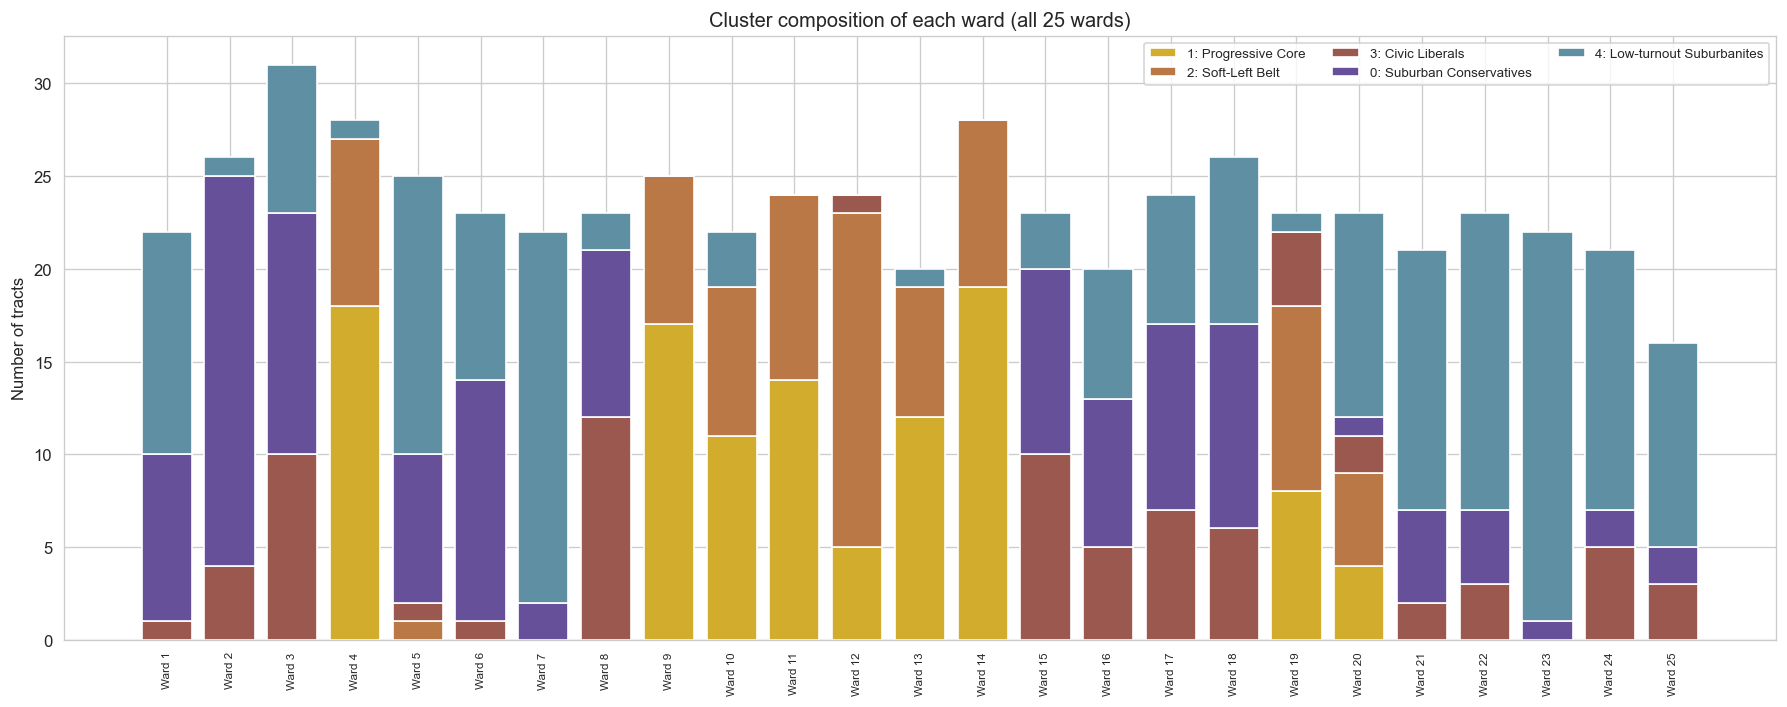

In [29]:
# ── Stacked bar: cluster composition of each ward, ordered by ward number ────────
fig, ax = plt.subplots(figsize=(15, 6))
ward_number_order = sorted(ward_counts.index, key=lambda w: int(w.replace("Ward ", "")))
plot_wards = ward_counts.loc[ward_number_order]
bottom = np.zeros(len(plot_wards))
for c in DISPLAY_ORDER:
    vals = plot_wards[f"{c}: {CLUSTER_LABELS[c]}"].values
    ax.bar(range(len(plot_wards)), vals, bottom=bottom, color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}")
    bottom += vals
ax.set_xticks(range(len(plot_wards))); ax.set_xticklabels(plot_wards.index, rotation=90, fontsize=7)
ax.set_ylabel("Number of tracts"); ax.set_title("Cluster composition of each ward (all 25 wards)")
ax.legend(fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()


**Reading this.** Wards are ordered by ward number above (1 → 25) for easy lookup rather than
by size or mix — so read the pattern by scanning bars, not by position in the chart. A handful
of wards are close to single-cluster: Ward 2 is almost entirely the Suburban Conservatives
group, Wards 4 and 14 are almost entirely the two progressive-leaning groups, and Wards 7 and
23 are almost entirely the Low-turnout Suburbanites group. Most other wards are genuine three- or
four-cluster mixes, with no single group holding a majority of that ward's tracts. So the
honest read is: **the wards that anchor the strongest progressive or the most suburban,
low-turnout areas are close to riding-shaped, but most of the city is not** — which is exactly
the kind of nuance a single-race, ward-level election map would flatten out.


In [30]:
# ── Top geographies for each cluster (by share of cluster's tracts) ──────────────
def top_geographies_table(share_of_cluster, top_n=5):
    out = {}
    for col in share_of_cluster.columns:
        top = share_of_cluster[col].sort_values(ascending=False).head(top_n)
        out[col] = [f"{geo} ({pct:.0f}%)" for geo, pct in top.items()]
    return pd.DataFrame(out).T

print("Top wards per cluster (share of that cluster's tracts found there):")
top_geographies_table(ward_share_of_cluster)


Top wards per cluster (share of that cluster's tracts found there):


,0,1,2,3,4
1: Progressive Core,Ward 14 (18%),Ward 4 (17%),Ward 9 (16%),Ward 11 (13%),Ward 13 (11%)
2: Soft-Left Belt,Ward 12 (21%),Ward 11 (12%),Ward 19 (12%),Ward 4 (11%),Ward 14 (11%)
3: Civic Liberals,Ward 8 (16%),Ward 3 (13%),Ward 15 (13%),Ward 17 (9%),Ward 18 (8%)
0: Suburban Conservatives,Ward 2 (16%),Ward 3 (10%),Ward 6 (10%),Ward 18 (9%),Ward 17 (8%)
4: Low-turnout Suburbanites,Ward 23 (11%),Ward 7 (11%),Ward 22 (9%),Ward 5 (8%),Ward 24 (8%)


In [31]:
print("Top provincial ridings per cluster:")
top_geographies_table(prov_share_of_cluster)


Top provincial ridings per cluster:


,0,1,2,3,4
1: Progressive Core,Toronto—Danforth (18%),Parkdale—High Park (17%),Davenport (16%),University—Rosedale (13%),Toronto Centre (11%)
2: Soft-Left Belt,Toronto—St. Paul's (21%),University—Rosedale (12%),Beaches—East York (12%),Toronto—Danforth (11%),Parkdale—High Park (11%)
3: Civic Liberals,Eglinton—Lawrence (16%),Etobicoke—Lakeshore (13%),Don Valley West (13%),Don Valley North (9%),Willowdale (8%)
0: Suburban Conservatives,Etobicoke Centre (16%),Etobicoke—Lakeshore (10%),York Centre (10%),Willowdale (9%),Don Valley West (8%)
4: Low-turnout Suburbanites,Scarborough North (11%),Humber River—Black Creek (11%),Scarborough—Agincourt (9%),York South—Weston (8%),Scarborough—Guildwood (8%)


In [32]:
print("Top federal ridings per cluster:")
top_geographies_table(fed_share_of_cluster)


Top federal ridings per cluster:


,0,1,2,3,4
1: Progressive Core,Taiaiako’n—Parkdale—High Park (18%),Toronto—Danforth (18%),University—Rosedale (17%),Davenport (16%),Toronto Centre (12%)
2: Soft-Left Belt,Toronto—St. Paul's (22%),Beaches—East York (12%),Taiaiako’n—Parkdale—High Park (12%),University—Rosedale (12%),Toronto—Danforth (11%)
3: Civic Liberals,Don Valley West (16%),Eglinton—Lawrence (16%),Etobicoke—Lakeshore (10%),Don Valley North (9%),Etobicoke Centre (9%)
0: Suburban Conservatives,Etobicoke Centre (14%),York Centre (10%),Etobicoke—Lakeshore (9%),Don Valley North (9%),Scarborough Centre—Don Valley East (9%)
4: Low-turnout Suburbanites,Scarborough North (13%),Humber River—Black Creek (11%),Scarborough—Agincourt (9%),Scarborough—Woburn (8%),York South—Weston—Etobicoke (7%)


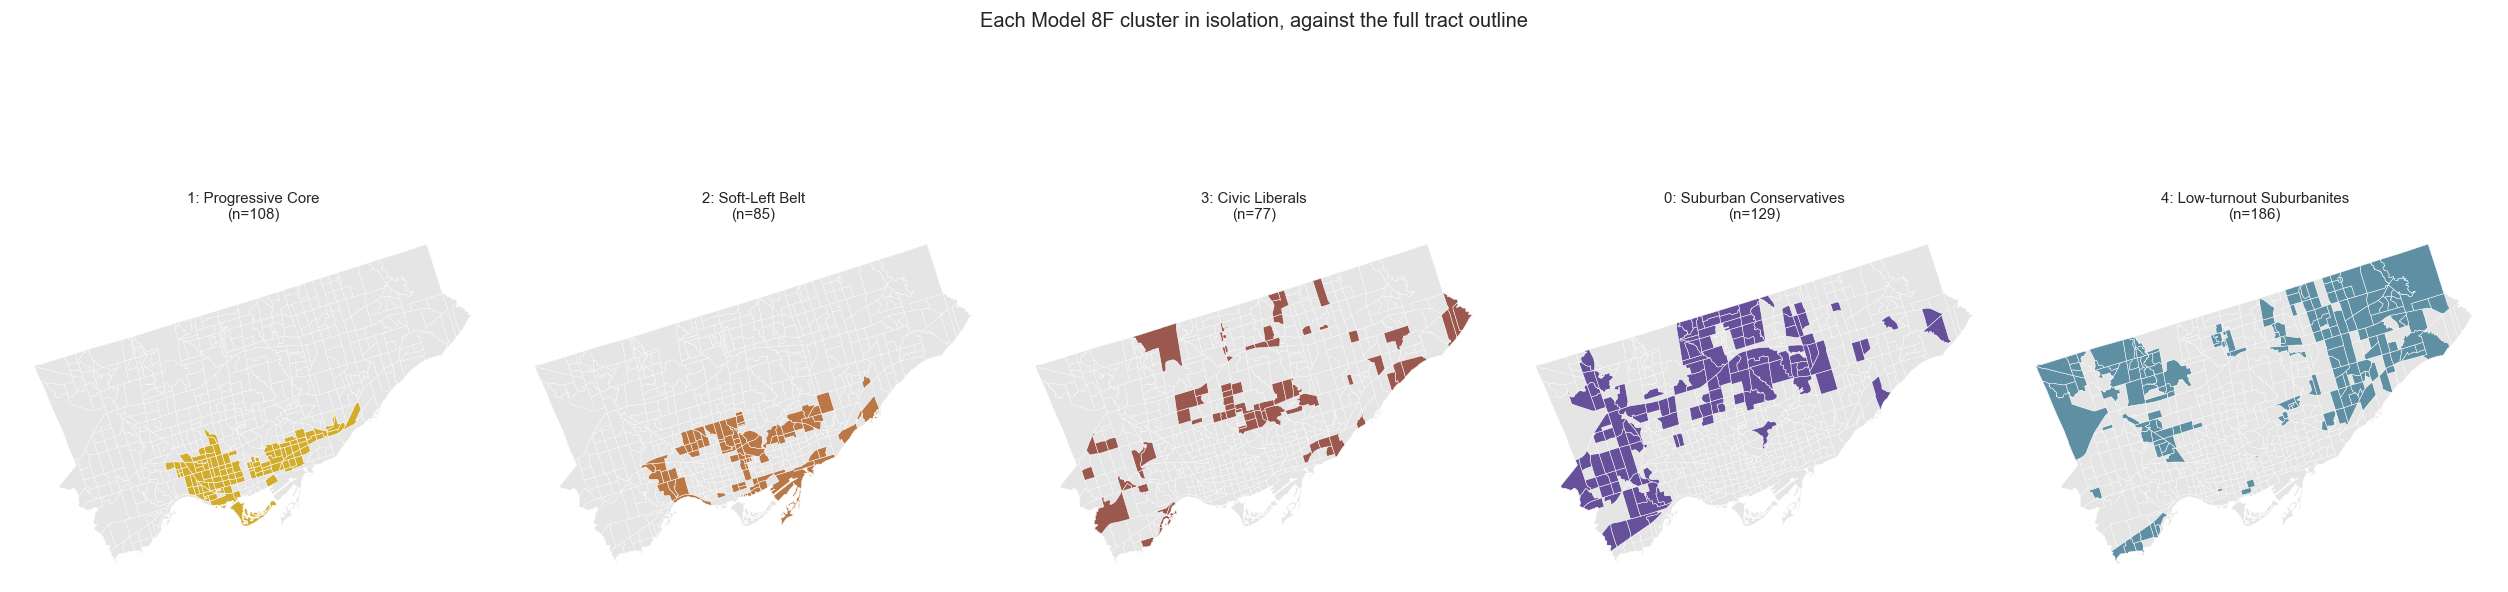

In [33]:
# ── Small maps isolating each cluster ─────────────────────────────────────────────
fig, axes = plt.subplots(1, K_CHOSEN, figsize=(4.2 * K_CHOSEN, 6))
for c, ax in zip(DISPLAY_ORDER, axes):
    tracts.plot(ax=ax, color="#e5e5e5", edgecolor="white", linewidth=0.2)
    tracts[tracts["cluster_8f"] == c].plot(ax=ax, color=PALETTE_BY_ID[c], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{c}: {CLUSTER_LABELS[c]}\n(n={cluster_sizes_8f[c]})", fontsize=9)
    ax.axis("off")
fig.suptitle("Each Model 8F cluster in isolation, against the full tract outline", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Reading this.** The five clusters differ sharply in spatial coherence:

- **The Progressive Core** and **Soft-Left Belt** are the most spatially coherent — each forms
  one compact, contiguous band along the downtown lakefront (the Soft-Left Belt wrapping around
  the core to its north and east), reading as a genuine, unified "old city" corridor rather than
  scattered pockets.
- **Suburban Conservatives** is mostly one large contiguous mass spanning Etobicoke and a
  central-north swath, with a couple of smaller detached islands elsewhere — still reasonably
  coherent, but not a single unbroken shape.
- **Low-turnout Suburbanites** is the largest group and forms several large, internally
  contiguous blobs (far northwest, far northeast/Scarborough, and a broad north-central swath)
  rather than one connected region — coherent within each of those areas, but split across three
  separate parts of the city.
- **Civic Liberals** is clearly the most fragmented of the five: separate clusters of tracts
  around the Etobicoke lakeshore, the Don Valley/Eglinton-Lawrence corridor, and the far east
  end, plus several small, standalone islands scattered near the core. This fits the story told
  in §3-§4: it is defined more by a specific demographic/turnout profile than by a single
  contiguous political geography, so a fragmented footprint is expected rather than a modelling
  concern.


## 6. Loading and Preparing the Census CT Data

`data/clustering_neighbourhoods/census/toronto-ct-small.csv` is a **long-form** 2021 Census
file, structured exactly like the ADA file used in an earlier version of this notebook — one
row per (geography, characteristic) pair — but at the **census tract (CT)** level, the same
geography our 8F clusters are built on. `census_ct_long` was already loaded in §3 to pull the
population column into the main profile table; here we inspect it properly and extract the
full demographic variable set.

**Why this is simpler than the ADA version:** a tract nests inside exactly one ADA, but roughly
80% of ADAs span *more than one* tract, which meant the ADA version had to disaggregate ADA
totals down to tracts by land area — an explicit modelling assumption, clearly caveated, but an
assumption nonetheless. The CT file needs none of that: **each of our 585 clustered tracts has
its own directly-published census record.** No allocation, no area-weighting, no split-geography
caveat. We still verify the join carefully below rather than assuming it's clean.


In [34]:
print(f"Rows: {len(census_ct_long)}  |  Unique CTs (GEO_NAME): {census_ct_long['GEO_NAME'].nunique()}  |  "
      f"Unique characteristics: {census_ct_long['CHARACTERISTIC_ID'].nunique()}")
print(f"Duplicate (GEO_NAME, CHARACTERISTIC_ID) rows: {census_ct_long.duplicated(['GEO_NAME', 'CHARACTERISTIC_ID']).sum()}")
print(f"GEO_NAME dtype: {census_ct_long['GEO_NAME'].dtype}  |  sample values: {sorted(census_ct_long['GEO_NAME'].unique())[:5]}")
census_ct_long.head(3)


Rows: 114448  |  Unique CTs (GEO_NAME): 622  |  Unique characteristics: 184
Duplicate (GEO_NAME, CHARACTERISTIC_ID) rows: 0
GEO_NAME dtype: float64  |  sample values: [np.float64(5350001.0), np.float64(5350002.0), np.float64(5350003.0), np.float64(5350004.0), np.float64(5350005.0)]


,GEO_NAME,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE,C1_COUNT_TOTAL,C10_RATE_TOTAL
0,5350001.0,1,"Population, 2021",pop_2021,599.0,NaN
1,5350001.0,2,"Population, 2016",pop_2016,595.0,NaN
2,5350001.0,3,"Population percentage change, 2016 to 2021",pop_pct_change,0.7,0.7


In [35]:
# Confirm the specific characteristic IDs requested in the brief actually exist with the
# names/codes expected, rather than assuming the CT file matches the ADA file's structure.
requested = census_ct_long[census_ct_long["CHARACTERISTIC_ID"].isin(CENSUS_CHAR_IDS)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates().sort_values("CHARACTERISTIC_ID").reset_index(drop=True)
print(f"{len(requested)} of {len(CENSUS_CHAR_IDS)} requested characteristic IDs found.")
requested


24 of 24 requested characteristic IDs found.


,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE
0,1,"Population, 2021",pop_2021
1,6,Population density per square kilometre,pop_density
2,37,65 years and over,age_65_over
3,39,Average age of the population,age_mean
4,50,Total - Private households by household size -...,pvt_house_total
5,57,Average household size,pvt_house_avg_size
6,113,Median total income in 2020 among recipien...,income_total_median
7,1414,Total - Private households by tenure - 25% sam...,housing_tenure_total
8,1416,Renter,housing_tenure_renter
9,1465,Total - Owner and tenant households with house...,housing_shelter_total


### Checking the commute-mode and commute-duration denominators

The brief asks us not to compute commute percentages without confirming the denominator. The
IDs immediately around the requested commute variables show the totals we need:


In [36]:
commute_context = census_ct_long[(census_ct_long["CHARACTERISTIC_ID"] >= 2598) & (census_ct_long["CHARACTERISTIC_ID"] <= 2620)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates().sort_values("CHARACTERISTIC_ID")
commute_context


,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE
170,2603,Total - Main mode of commuting for the employe...,commute_mode_total
171,2604,"Car, truck or van",commute_mode_car_truck_van
172,2605,"Car, truck or van - as a driver",commute_mode_car_driver
173,2606,"Car, truck or van - as a passenger",commute_mode_car_passenger
174,2607,Public transit,commute_mode_transit
175,2608,Walked,commute_mode_walked
176,2609,Bicycle,commute_mode_bicycle
177,2610,Other method,commute_mode_other
178,2611,Total - Commuting duration for the employed la...,commute_duration_total
179,2612,Less than 15 minutes,commute_duration_under15


**Confirmed:** `commute_mode_total` (ID 2603) is the correct denominator for car/truck/van
(2604) and public-transit (2607) shares; `commute_duration_total` (ID 2611) is the correct
denominator for the 60-minutes-and-over share (2616). Both are distinct universes (main mode of
commuting vs. commuting duration) even though they happen to carry the same total count for most
tracts in this data.

### A data quirk worth flagging: `age_65_over` is not a raw count

Checking characteristic IDs 34–40 shows `age_65_over` (ID 37) sits inside a **distribution-of-
population-by-age-group (%)** block — ID 34's value is 100.0 for every tract, confirming the
whole block is percentages, not head counts. So `age_65_over`'s value in this file is already
"% of the tract's population aged 65+", not a count (this is the same quirk found in the ADA
file — it's a property of how this StatCan table is structured, not something specific to
either geography level). Every other requested variable *is* a genuine additive count (verified
below), so we handle this one variable differently: we reconstruct an implied head count as
`age_65_over_pct / 100 * pop_2021` before aggregating, so that cluster-level percentages are
still population-weighted rather than an unweighted average of tract percentages.


In [37]:
# Sanity-check that every other requested "count" variable is genuinely additive, by confirming
# its published rate matches count/denominator to within rounding.
CENSUS_VARS = [
    # name                          id     kind        numerator                    denominator
    ("pop_2021",                    1,     "count",    "pop_2021",                  None),
    ("pop_density",                 6,     "density",  "pop_density",               None),
    ("age_65_over_pct",             37,    "pct_only", "age_65_over",                "pop_2021"),   # see note above
    ("age_mean",                    39,    "avg_pop_weighted", "age_mean",           "pop_2021"),
    ("pvt_house_total",             50,    "count",    "pvt_house_total",            None),
    ("pvt_house_avg_size",          57,    "avg_hh_weighted",  "pvt_house_avg_size",  "pvt_house_total"),
    ("income_total_median",        113,    "median_approx",    "income_total_median","pop_2021"),
    ("housing_tenure_total",      1414,    "count",    "housing_tenure_total",       None),
    ("housing_tenure_renter",     1416,    "count",    "housing_tenure_renter",      "housing_tenure_total"),
    ("housing_shelter_total",     1465,    "count",    "housing_shelter_total",      None),
    ("housing_shelter_30plus",    1467,    "count",    "housing_shelter_30plus",     "housing_shelter_total"),
    ("citizen_total",             1522,    "count",    "citizen_total",              None),
    ("citizen_canadian",          1523,    "count",    "citizen_canadian",           "citizen_total"),
    ("visible_minority_total",    1683,    "count",    "visible_minority_total",     None),
    ("visible_minority_yes",      1684,    "count",    "visible_minority_yes",       "visible_minority_total"),
    ("mobility_total",            1983,    "count",    "mobility_total",             None),
    ("mobility_migrants",         1987,    "count",    "mobility_migrants",          "mobility_total"),
    ("education_total",           1998,    "count",    "education_total",           None),
    ("education_bachelor_higher", 2008,    "count",    "education_bachelor_higher",  "education_total"),
    ("commute_mode_total",        2603,    "count",    "commute_mode_total",         None),
    ("commute_mode_car_truck_van",2604,    "count",    "commute_mode_car_truck_van", "commute_mode_total"),
    ("commute_mode_transit",      2607,    "count",    "commute_mode_transit",       "commute_mode_total"),
    ("commute_duration_total",    2611,    "count",    "commute_duration_total",     None),
    ("commute_duration_60plus",   2616,    "count",    "commute_duration_60plus",    "commute_duration_total"),
]
var_dict = pd.DataFrame(CENSUS_VARS, columns=["output_variable", "characteristic_id", "kind", "numerator_code", "denominator_code"])
var_dict["cluster_aggregation"] = var_dict["kind"].map({
    "count":              "sum numerator across cluster's tracts",
    "density":            "sum(population) / sum(area_km2), using each tract's own geometry (§2)",
    "pct_only":           "reconstruct count = pct/100 * pop_2021, then sum(count) / sum(pop_2021)",
    "avg_pop_weighted":   "population-weighted average of tract values",
    "avg_hh_weighted":    "household-weighted average of tract values",
    "median_approx":      "population-weighted average of tract medians (NOT a true cluster median — see caveat)",
})
var_dict


,output_variable,characteristic_id,kind,numerator_code,denominator_code,cluster_aggregation
0,pop_2021,1,count,pop_2021,None,sum numerator across cluster's tracts
1,pop_density,6,density,pop_density,None,"sum(population) / sum(area_km2), using each tr..."
2,age_65_over_pct,37,pct_only,age_65_over,pop_2021,"reconstruct count = pct/100 * pop_2021, then s..."
3,age_mean,39,avg_pop_weighted,age_mean,pop_2021,population-weighted average of tract values
4,pvt_house_total,50,count,pvt_house_total,None,sum numerator across cluster's tracts
5,pvt_house_avg_size,57,avg_hh_weighted,pvt_house_avg_size,pvt_house_total,household-weighted average of tract values
6,income_total_median,113,median_approx,income_total_median,pop_2021,population-weighted average of tract medians (...
7,housing_tenure_total,1414,count,housing_tenure_total,None,sum numerator across cluster's tracts
8,housing_tenure_renter,1416,count,housing_tenure_renter,housing_tenure_total,sum numerator across cluster's tracts
9,housing_shelter_total,1465,count,housing_shelter_total,None,sum numerator across cluster's tracts


In [38]:
# ── Build the wide CT-level table ─────────────────────────────────────────────────
code_list = sorted(set(v[3] for v in CENSUS_VARS))
census_ct_wide = census_ct_long[census_ct_long["CHARACTERISTIC_CODE"].isin(code_list)].pivot(
    index="GEO_NAME", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL"
)
census_ct_wide.index = census_ct_wide.index.map(lambda x: f"{x:.2f}")   # match tracts["ct_id"] formatting
census_ct_wide.index.name = "ct_id"

missing = census_ct_wide.isna().sum()
print("Missing values per column (2 tracts have confidentiality-suppressed 25%-sample values; see below):")
print(missing[missing > 0].to_string() if missing.any() else "  none")

# Reconstruct the implied 65+ head count from the published percentage (see note above).
census_ct_wide["age_65_over_count"] = census_ct_wide["age_65_over"] / 100.0 * census_ct_wide["pop_2021"]

print(f"\nWide CT table: {census_ct_wide.shape[0]} tracts x {census_ct_wide.shape[1]} columns")
census_ct_wide.head(3)


Missing values per column (2 tracts have confidentiality-suppressed 25%-sample values; see below):
CHARACTERISTIC_CODE
citizen_canadian              2
citizen_total                 2
commute_duration_60plus       2
commute_duration_total        2
commute_mode_car_truck_van    2
commute_mode_total            2
commute_mode_transit          2
education_bachelor_higher     2
education_total               2
housing_shelter_30plus        2
housing_shelter_total         2
housing_tenure_renter         2
housing_tenure_total          2
income_total_median           2
mobility_migrants             2
mobility_total                2
pvt_house_avg_size            2
visible_minority_total        2
visible_minority_yes          2

Wide CT table: 622 tracts x 25 columns


CHARACTERISTIC_CODE,age_65_over,age_mean,citizen_canadian,citizen_total,commute_duration_60plus,commute_duration_total,commute_mode_car_truck_van,commute_mode_total,commute_mode_transit,education_bachelor_higher,...,income_total_median,mobility_migrants,mobility_total,pop_2021,pop_density,pvt_house_avg_size,pvt_house_total,visible_minority_total,visible_minority_yes,age_65_over_count
ct_id,,,,,,,,,,,,,,,,,,,,,
5350001.00,10.0,38.9,555.0,590.0,0.0,180.0,110.0,180.0,25.0,260.0,...,57200.0,45.0,545.0,599.0,87.8,2.6,235.0,590.0,185.0,59.900
5350002.00,42.1,55.0,590.0,600.0,10.0,115.0,35.0,115.0,25.0,245.0,...,40800.0,20.0,580.0,604.0,178.0,2.1,280.0,600.0,10.0,254.284
5350003.00,11.0,39.6,400.0,520.0,20.0,195.0,130.0,195.0,40.0,245.0,...,59200.0,205.0,480.0,457.0,483.3,1.7,265.0,525.0,275.0,50.270


### QA: verifying the tract-ID join before trusting it

Before joining, we check the ID fields on both sides directly rather than assuming they line
up: `tracts["ct_id"]` is a zero-padded string (e.g. `"5350001.00"`), while
`census_ct_wide`'s index started life as a `float64` `GEO_NAME` (e.g. `5350001.0`) — we
formatted it above with `f"{x:.2f}"` to match. The checks below confirm that formatting choice
actually produces a clean 1:1 join, rather than trusting it silently.


In [39]:
n_tracts_8f = len(tracts)
n_ct_census_records = census_ct_wide.shape[0]
n_dup_ct_ids = tracts["ct_id"].duplicated().sum() + pd.Series(census_ct_wide.index).duplicated().sum()

matched_ids = set(tracts["ct_id"]) & set(census_ct_wide.index)
unmatched_tract_ids = set(tracts["ct_id"]) - set(census_ct_wide.index)
unmatched_census_ids = set(census_ct_wide.index) - set(tracts["ct_id"])

qa = pd.DataFrame({
    "metric": [
        "Tracts in 8F cluster data", "CT census records (full file, incl. tracts outside our 585)",
        "Matched tracts", "Unmatched tracts (in 8F data, no census record)",
        "Census records not used (outside our 585 clustered tracts)", "Duplicated tract IDs (either side)",
    ],
    "value": [
        n_tracts_8f, n_ct_census_records, len(matched_ids), len(unmatched_tract_ids),
        len(unmatched_census_ids), n_dup_ct_ids,
    ],
})
print(qa.to_string(index=False))
if unmatched_tract_ids:
    print("\nUnmatched tract IDs:", sorted(unmatched_tract_ids))
assert len(unmatched_tract_ids) == 0 and n_dup_ct_ids == 0, "Census join is not clean — stop and investigate."
print("\n✅ Every one of the 585 clustered tracts has exactly one matching CT census record.")


                                                     metric  value
                                  Tracts in 8F cluster data    585
CT census records (full file, incl. tracts outside our 585)    622
                                             Matched tracts    585
            Unmatched tracts (in 8F data, no census record)      0
 Census records not used (outside our 585 clustered tracts)     37
                         Duplicated tract IDs (either side)      0

✅ Every one of the 585 clustered tracts has exactly one matching CT census record.


In [40]:
# ── Direct join: one row per tract, no allocation ─────────────────────────────────
ct_census = tracts[["ct_id", "cluster_8f", "cluster_label", "area_km2"]].merge(census_ct_wide, on="ct_id", how="left")

pop_total = ct_census["pop_2021"].sum()
coverage_by_cluster = ct_census.groupby("cluster_8f").agg(
    n_tracts=("ct_id", "count"), population=("pop_2021", "sum"),
).reindex(DISPLAY_ORDER)
coverage_by_cluster["label"] = [CLUSTER_LABELS[c] for c in DISPLAY_ORDER]
coverage_by_cluster["pct_of_city_population"] = 100 * coverage_by_cluster["population"] / pop_total
coverage_by_cluster = coverage_by_cluster[["label", "n_tracts", "population", "pct_of_city_population"]]
coverage_by_cluster.round(1)


,label,n_tracts,population,pct_of_city_population
cluster_8f,,,,
1,Progressive Core,108,486531.0,17.4
2,Soft-Left Belt,85,415371.0,14.9
3,Civic Liberals,77,384610.0,13.8
0,Suburban Conservatives,129,615714.0,22.0
4,Low-turnout Suburbanites,186,892130.0,31.9


**Two tracts (out of 585) have suppressed 25%-sample-based values** (`5350006.00` and
`5350205.00`, both small-population tracts) — Statistics Canada withholds sample-based counts
(citizenship, education, commuting, housing tenure, etc.) below a confidentiality threshold.
Their 100%-data variables (population, density, age) are unaffected. Every aggregation below
uses `.sum()`/weighted averages that skip missing values by default, so these two tracts simply
contribute nothing to the *sample-based* sums rather than being (incorrectly) treated as zero —
a negligible effect at cluster level given 585 tracts total, but worth stating plainly rather
than leaving as a silent gap.


## 7. Demographic Profile of Each Cluster

We now aggregate the tract-level census data up to the five 8F clusters, following the rules
in the brief: counts are **summed** then divided (never averaged as percentages), density is
derived from summed population over summed area, and the two genuine averages (mean age,
household size) are aggregate-weighted rather than simple means of tract values. Median income
is flagged as an approximation — see the caveat below.


In [41]:
def aggregate_demographics(df, weight_pop="pop_2021"):
    # df: tract-level rows for one group (cluster or all of Toronto).
    # Returns a dict of cluster-level demographic statistics. Uses pandas'/numpy's default
    # NaN-skipping sum/average, so the two tracts with suppressed sample-based values (§6)
    # simply don't contribute to those particular sums rather than being treated as zero.
    pop = df[weight_pop].sum()
    age_valid = df.dropna(subset=["age_mean", weight_pop])
    hh_valid = df.dropna(subset=["pvt_house_avg_size", "pvt_house_total"])
    income_valid = df.dropna(subset=["income_total_median", weight_pop])
    out = {
        "population": pop,
        "area_km2": df["area_km2"].sum(),
        "pop_density_per_km2": pop / df["area_km2"].sum() if df["area_km2"].sum() > 0 else np.nan,
        "pct_age_65_over": 100 * df["age_65_over_count"].sum() / pop,
        "avg_age": np.average(age_valid["age_mean"], weights=age_valid[weight_pop]),
        "avg_household_size": np.average(hh_valid["pvt_house_avg_size"], weights=hh_valid["pvt_house_total"]),
        "median_income_approx": np.average(income_valid["income_total_median"], weights=income_valid[weight_pop]),
        "pct_renter": 100 * df["housing_tenure_renter"].sum() / df["housing_tenure_total"].sum(),
        "pct_shelter_burdened_30plus": 100 * df["housing_shelter_30plus"].sum() / df["housing_shelter_total"].sum(),
        "pct_canadian_citizen": 100 * df["citizen_canadian"].sum() / df["citizen_total"].sum(),
        "pct_visible_minority": 100 * df["visible_minority_yes"].sum() / df["visible_minority_total"].sum(),
        "pct_migrant_5yr": 100 * df["mobility_migrants"].sum() / df["mobility_total"].sum(),
        "pct_bachelor_or_higher": 100 * df["education_bachelor_higher"].sum() / df["education_total"].sum(),
        "pct_commute_car": 100 * df["commute_mode_car_truck_van"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_transit": 100 * df["commute_mode_transit"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_60plus_min": 100 * df["commute_duration_60plus"].sum() / df["commute_duration_total"].sum(),
    }
    return out

demo_rows = {CLUSTER_LABELS[c]: aggregate_demographics(ct_census[ct_census["cluster_8f"] == c]) for c in range(K_CHOSEN)}
demo_rows["Toronto (all tracts)"] = aggregate_demographics(ct_census)
demographics = pd.DataFrame(demo_rows).T
demographics.round(1)


,population,area_km2,pop_density_per_km2,pct_age_65_over,avg_age,avg_household_size,median_income_approx,pct_renter,pct_shelter_burdened_30plus,pct_canadian_citizen,pct_visible_minority,pct_migrant_5yr,pct_bachelor_or_higher,pct_commute_car,pct_commute_transit,pct_commute_60plus_min
Suburban Conservatives,615714.0,203.9,3020.2,20.2,43.3,2.7,42018.8,36.8,28.4,85.2,48.0,12.7,38.8,71.2,21.4,11.7
Progressive Core,486531.0,54.1,8989.3,13.7,40.3,2.0,43859.0,58.4,33.9,86.1,41.6,18.1,47.9,42.2,30.8,10.1
Soft-Left Belt,415371.0,67.7,6133.2,16.1,41.1,2.0,53114.7,53.2,36.4,83.2,39.0,22.7,55.5,48.5,27.0,9.1
Civic Liberals,384610.0,95.9,4009.7,19.0,42.6,2.2,46547.8,43.8,33.3,83.1,49.9,18.0,47.7,63.8,25.7,11.3
Low-turnout Suburbanites,892130.0,244.3,3651.5,16.3,40.5,2.8,33462.2,47.5,31.4,78.8,78.7,15.7,28.9,66.5,27.2,15.7
Toronto (all tracts),2794356.0,666.0,4196.0,17.1,41.5,2.4,41880.9,48.1,32.5,82.7,55.7,16.8,41.1,61.0,26.2,12.5


**Caveat on `median_income_approx`:** published medians cannot be summed or exactly re-derived
from smaller geographies. This is a **population-weighted average of tract-level published
medians** ("Approx. median income" / "population-weighted tract median income" — used
interchangeably below), a reasonable approximation of central tendency but *not* a recomputed
true median for the cluster. No better weighting field (e.g. income-recipient counts) is
available in this extract, so population is the weight used throughout. Treat this variable as
directionally informative, not exact — it is the single least precise number in this section.


In [42]:
# ── Comparison to the Toronto-wide benchmark: difference, rank, and index (Toronto = 100) ──
toronto_row = demographics.loc["Toronto (all tracts)"]
cluster_demo = demographics.drop(index="Toronto (all tracts)")
cluster_demo.index = range(K_CHOSEN)   # align to cluster IDs 0..4

comparison_frames = {}
for col in cluster_demo.columns:
    diff = cluster_demo[col] - toronto_row[col]
    rank = cluster_demo[col].rank(ascending=False).astype(int)
    index100 = 100 * cluster_demo[col] / toronto_row[col]
    comparison_frames[col] = pd.DataFrame({
        "cluster_value": cluster_demo[col], "toronto_value": toronto_row[col],
        "diff_vs_toronto": diff, "rank_1_is_highest": rank, "index_toronto_100": index100,
    })

# A single flat table: one row per (cluster, variable), for later filtering/plotting.
demo_long = pd.concat(
    {col: frame for col, frame in comparison_frames.items()}, names=["variable", "cluster"]
).reset_index()
demo_long["cluster_label"] = demo_long["cluster"].map(CLUSTER_LABELS)
demo_long.head(8)


,variable,cluster,cluster_value,toronto_value,diff_vs_toronto,rank_1_is_highest,index_toronto_100,cluster_label
0,population,0,615714.000000,2.794356e+06,-2.178642e+06,2,22.034200,Suburban Conservatives
1,population,1,486531.000000,2.794356e+06,-2.307825e+06,3,17.411203,Progressive Core
2,population,2,415371.000000,2.794356e+06,-2.378985e+06,4,14.864641,Soft-Left Belt
3,population,3,384610.000000,2.794356e+06,-2.409746e+06,5,13.763815,Civic Liberals
4,population,4,892130.000000,2.794356e+06,-1.902226e+06,1,31.926140,Low-turnout Suburbanites
5,area_km2,0,203.867531,6.659521e+02,-4.620846e+02,2,30.612941,Suburban Conservatives
6,area_km2,1,54.123154,6.659521e+02,-6.118290e+02,5,8.127184,Progressive Core
7,area_km2,2,67.724692,6.659521e+02,-5.982274e+02,4,10.169604,Soft-Left Belt


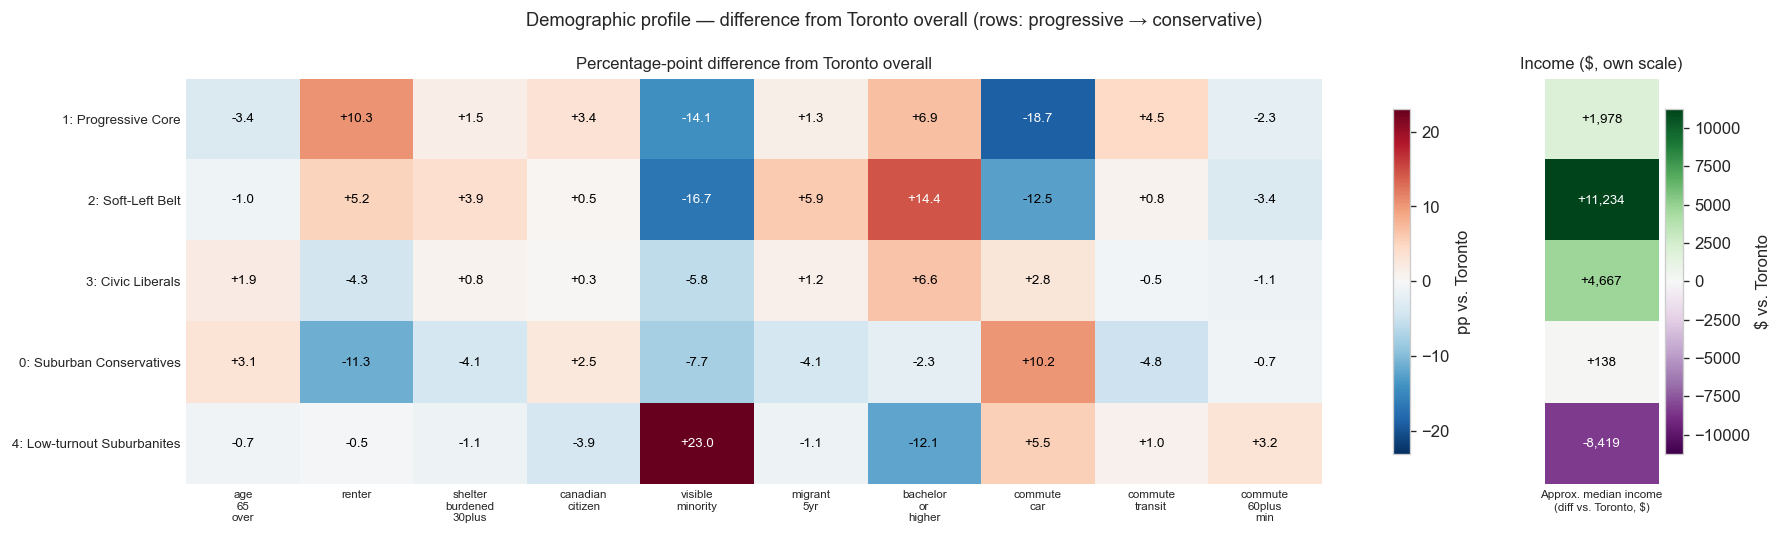

In [43]:
# ── Demographic heatmap: cluster deviation from Toronto ───────────────────────────
# Percentage-point variables and the income measure are on different scales (pp vs. dollars),
# so income gets its own colour-normalised column rather than being forced onto the pp scale.
pct_vars = ["pct_age_65_over", "pct_renter", "pct_shelter_burdened_30plus", "pct_canadian_citizen",
            "pct_visible_minority", "pct_migrant_5yr", "pct_bachelor_or_higher",
            "pct_commute_car", "pct_commute_transit", "pct_commute_60plus_min"]
other_vars = ["pop_density_per_km2", "avg_age", "avg_household_size", "median_income_approx"]

heat_pct = pd.DataFrame({v: comparison_frames[v]["diff_vs_toronto"] for v in pct_vars})
heat_pct.index = [f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)]
heat_pct = heat_pct.loc[[f"{c}: {CLUSTER_LABELS[c]}" for c in DISPLAY_ORDER]]

heat_income = pd.DataFrame({"Approx. median income\n(diff vs. Toronto, $)": comparison_frames["median_income_approx"]["diff_vs_toronto"]})
# Assign raw-ID-ordered labels first, then reindex to the same display order as heat_pct --
# assigning heat_pct.index directly here (as an earlier version of this cell did) attaches
# heat_pct's *already display-order-sorted* labels to heat_income's *still-raw-ID-ordered*
# values, silently mismatching every row except the one where raw ID and display order happen
# to coincide. `.loc[]` moves data and label together, the way heat_pct's own line above does.
heat_income.index = [f"{c}: {CLUSTER_LABELS[c]}" for c in range(K_CHOSEN)]
heat_income = heat_income.loc[heat_pct.index]

fig, (ax_pct, ax_income) = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [len(pct_vars), 1]})
vmax = np.abs(heat_pct.values).max()
im1 = ax_pct.imshow(heat_pct.values, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
for i in range(heat_pct.shape[0]):
    for j in range(heat_pct.shape[1]):
        val = heat_pct.values[i, j]
        txt_color = "white" if abs(val) / vmax > 0.6 else "black"
        ax_pct.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=8, color=txt_color)
ax_pct.set_xticks(range(len(pct_vars))); ax_pct.set_xticklabels([v.replace("pct_", "").replace("_", "\n") for v in pct_vars], fontsize=7)
ax_pct.set_yticks(range(len(heat_pct))); ax_pct.set_yticklabels(heat_pct.index, fontsize=8)
ax_pct.set_title("Percentage-point difference from Toronto overall", fontsize=10)

vmax_income = np.abs(heat_income.values).max()
im2 = ax_income.imshow(heat_income.values, cmap="PRGn", aspect="auto", vmin=-vmax_income, vmax=vmax_income)
for i in range(heat_income.shape[0]):
    val = heat_income.values[i, 0]
    txt_color = "white" if abs(val) / vmax_income > 0.6 else "black"
    ax_income.text(0, i, f"{val:+,.0f}", ha="center", va="center", fontsize=8, color=txt_color)
ax_income.set_xticks([0]); ax_income.set_xticklabels(heat_income.columns, fontsize=7)
ax_income.set_yticks([])
ax_income.set_title("Income ($, own scale)", fontsize=10)

# imshow heatmaps otherwise pick up the notebook-wide seaborn "whitegrid" style, which draws
# grid lines straight through the annotated cells — turn grids/ticks/spines off explicitly.
for ax in (ax_pct, ax_income):
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.colorbar(im1, ax=ax_pct, label="pp vs. Toronto", shrink=0.85)
fig.colorbar(im2, ax=ax_income, label="$ vs. Toronto", shrink=0.85)
fig.suptitle("Demographic profile — difference from Toronto overall (rows: progressive → conservative)", fontsize=11)
plt.tight_layout()
plt.show()


**Reading this.** The clearest, most consistent pattern in this heatmap is **visible minority
share**, and it cuts in a specific direction: Low-turnout Suburbanites (the largest cluster)
sits far *above* the Toronto average (+23pp), while every other cluster sits below it — most
sharply the Progressive Core and Soft-Left Belt (-14pp and -17pp respectively). We report this
because it is a real, large pattern in the aggregate tract data — but we are deliberately
neutral about what it means: it is an ecological, tract-level association alongside a political-
lean and turnout pattern, not a claim about how anyone voted or why, and that cluster's other
distinguishing features (below-average post-secondary attainment, the lowest approximate income
of the five groups in the panel to the right, above-average car commuting) describe a broader
outer-suburban profile that visible-minority share is only one part of. Beyond that: renter
share and bachelor's-attainment move together with the two NDP-leaning clusters (the Progressive
Core and Soft-Left Belt both sit above the city average on both), and car-commuting runs highest
in the two most PC/Conservative-leaning clusters (Suburban Conservatives and Low-turnout
Suburbanites). On income specifically: Soft-Left Belt has the highest approximate median income
of the five groups, and Low-turnout Suburbanites has the lowest — the same cluster that stands
out on visible-minority share also stands out, in the opposite direction, on income.


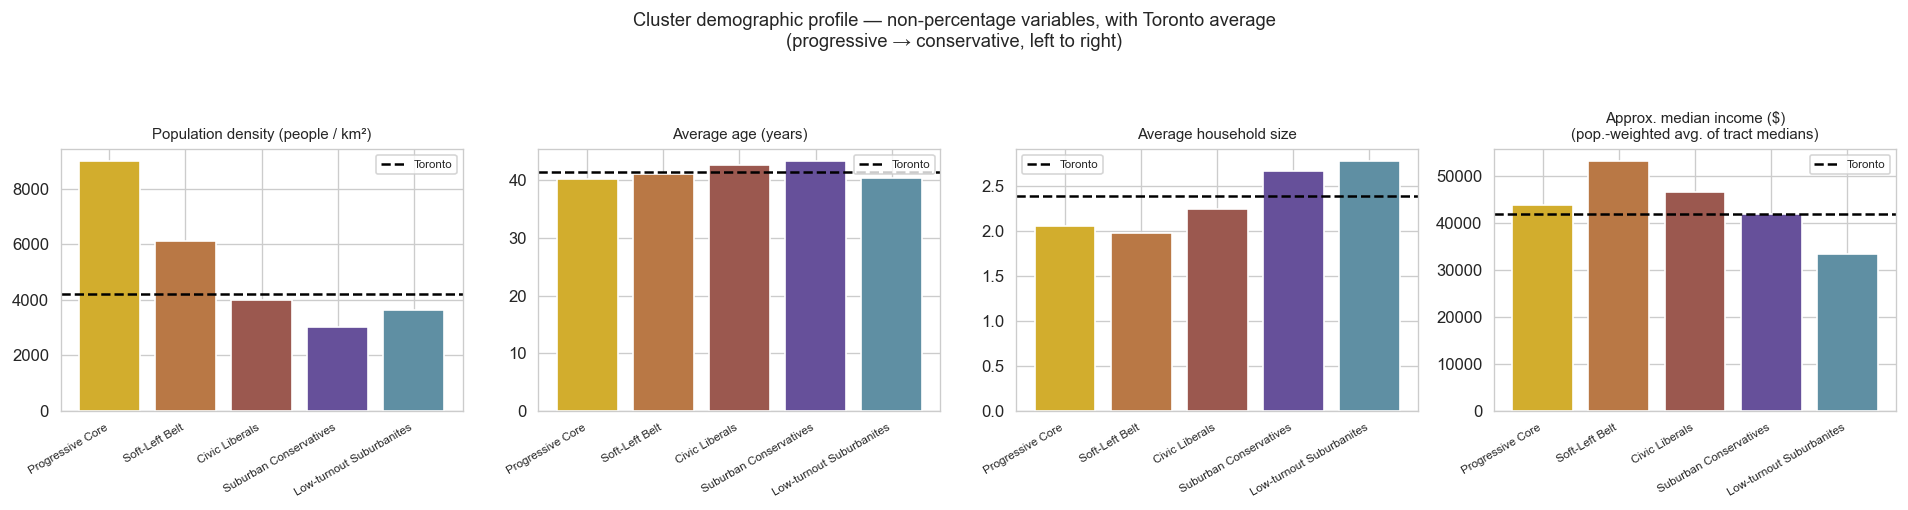

In [44]:
# ── Bar charts for the "other" (non-percentage) variables, each on its own natural scale ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = {"pop_density_per_km2": "Population density (people / km²)", "avg_age": "Average age (years)",
          "avg_household_size": "Average household size", "median_income_approx": "Approx. median income ($)\n(pop.-weighted avg. of tract medians)"}
for ax, col in zip(axes, other_vars):
    vals = cluster_demo.loc[DISPLAY_ORDER, col]
    ax.bar(range(K_CHOSEN), vals.values, color=[PALETTE_BY_ID[c] for c in DISPLAY_ORDER])
    ax.axhline(toronto_row[col], color="black", lw=1.5, linestyle="--", label="Toronto")
    ax.set_xticks(range(K_CHOSEN)); ax.set_xticklabels([CLUSTER_SHORT_LABELS[c] for c in DISPLAY_ORDER], rotation=30, ha="right", fontsize=7)
    ax.set_title(titles[col], fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("Cluster demographic profile — non-percentage variables, with Toronto average\n(progressive → conservative, left to right)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


**Reading this.** The Progressive Core and Soft-Left Belt are by a wide margin the two
densest, smallest-household-size groups (~9,000 and ~6,100 people/km² respectively, both well
above the ~3,000-4,000/km² range for the other three) — a compact, high-density inner-city
profile, with Soft-Left Belt's household size (1.97) edging out the Progressive Core's (2.05)
as the single smallest. Suburban Conservatives and Low-turnout Suburbanites are the two
least-dense groups (~3,000 and ~3,650 people/km² respectively), consistent with §5's map showing
them anchored in the outer and central-north parts of the city. On income: Soft-Left Belt has
the highest approximate median income of the five groups (~$53k vs. a citywide ~$42k), while
Low-turnout Suburbanites has the lowest (~$33k) alongside the largest average household size
(2.77) — again, remembering that `median_income_approx` is the population-weighted average of
published tract medians (caveat above), not a recomputed true cluster median. Average age is
fairly flat across all five groups (40-43 years, within about three years of each other) — age
is not a strong differentiator here, unlike density, income, or renter share.


## 8. Tract-Level Political Lean vs. Demographics

The cluster-level tables above average away a lot of tract-to-tract variation. Here we look
directly at the 585 tracts, relating a small set of **political lean measures** to demographic
variables. This is a **descriptive, ecological (tract-level) correlation exercise only**: it
says nothing about how any individual voted, and correlation here is not evidence of causation
in either direction.

### Defining the lean measures

City-relative deviations for different parties/candidates aren't automatically comparable,
because their citywide baselines differ hugely — federal NDP's citywide share is 6.4%, so its
pp deviations range over a much narrower band than provincial NDP's, whose citywide share is
23.3%. Averaging *raw* pp deviations would let the highest-baseline election dominate a
composite score. So every lean measure below is built the same way:

1. Take each column's **city-relative deviation** (tract minus citywide, in vote-share units —
   the `_vs_city` columns already computed in §2).
2. **Standardize** each column across all 585 tracts (z-score: subtract the column mean,
   divide by its standard deviation).
3. **Average** the standardized columns that make up the measure.

This gives every underlying election equal say in the composite, regardless of how large that
party's citywide baseline (and therefore its raw pp range) happens to be.

- **Chow/NDP lean** = mean of standardized (`mun_chow_vs_city`, `prov_ndp_vs_city`, `fed_ndp_vs_city`)
- **PC/Conservative lean** = mean of standardized (`prov_pc_vs_city`, `fed_conservative_vs_city`)
  — Bailão is left out of this measure: her 2023 mayoral run doesn't map onto a PC/Conservative
  ballot line as directly as the provincial PC and federal Conservative votes do, and including
  her would mix a candidate-specific race into a two-election party-line composite.
- **Liberal/localist lean** = mean of standardized (`prov_liberal_vs_city`, `fed_liberal_vs_city`,
  `mun_matlow_vs_city`) — explicitly the most heterogeneous of the three, mixing two party votes
  with one candidate's municipal result on purpose, as a single composite "moderate/
  Liberal-leaning" measure for the scatter plots below. Read it as "how localist/Liberal-leaning",
  not as a clean single-party measure, and not as a claim that this exact mix is any one
  cluster's own defining feature (§9 finds Civic Liberals' actual signature is specifically
  provincial Liberal strength, not Matlow's municipal result -- see §3, §9).


In [45]:
def standardized_lean(df, cols):
    z = (df[cols] - df[cols].mean()) / df[cols].std()
    return z.mean(axis=1)

tracts["chow_ndp_lean"]      = standardized_lean(tracts, ["mun_chow_vs_city", "prov_ndp_vs_city", "fed_ndp_vs_city"])
tracts["pc_con_lean"]        = standardized_lean(tracts, ["prov_pc_vs_city", "fed_conservative_vs_city"])
tracts["liberal_localist_lean"] = standardized_lean(tracts, ["prov_liberal_vs_city", "fed_liberal_vs_city", "mun_matlow_vs_city"])
tracts["avg_turnout_pct"] = 100 * tracts[TURNOUT_COLS].mean(axis=1)

print("Lean measures by cluster mean (standardized units; 0 = citywide average, roughly +/-1 = 1 SD):")
tracts.groupby("cluster_8f")[["chow_ndp_lean", "pc_con_lean", "liberal_localist_lean"]].mean().loc[DISPLAY_ORDER].round(2)


Lean measures by cluster mean (standardized units; 0 = citywide average, roughly +/-1 = 1 SD):


,chow_ndp_lean,pc_con_lean,liberal_localist_lean
cluster_8f,,,
1,1.48,-1.36,-0.02
2,0.43,-0.65,0.41
3,-0.58,0.23,0.46
0,-0.80,0.96,-0.29
4,-0.26,0.33,-0.17


In [46]:
# ── Merge in the per-tract demographic variables used in the scatterplots below ──
scatter_df = tracts.merge(
    ct_census[["ct_id", "pop_2021", "area_km2", "housing_tenure_renter", "housing_tenure_total",
               "education_bachelor_higher", "education_total", "commute_mode_car_truck_van",
               "commute_mode_transit", "commute_mode_total", "visible_minority_yes",
               "visible_minority_total", "age_65_over_count", "income_total_median"]],
    on="ct_id", how="left", suffixes=("", "_census"),
)
scatter_df["pct_renter"] = 100 * scatter_df["housing_tenure_renter"] / scatter_df["housing_tenure_total"]
scatter_df["pct_bachelor_or_higher"] = 100 * scatter_df["education_bachelor_higher"] / scatter_df["education_total"]
scatter_df["pct_commute_car"] = 100 * scatter_df["commute_mode_car_truck_van"] / scatter_df["commute_mode_total"]
scatter_df["pct_commute_transit"] = 100 * scatter_df["commute_mode_transit"] / scatter_df["commute_mode_total"]
scatter_df["pct_visible_minority"] = 100 * scatter_df["visible_minority_yes"] / scatter_df["visible_minority_total"]
scatter_df["pct_age_65_over"] = 100 * scatter_df["age_65_over_count"] / scatter_df["pop_2021"]
scatter_df["pop_density"] = scatter_df["pop_2021"] / scatter_df["area_km2"]

def tract_scatter(ax, xcol, ycol, xlabel, ylabel, title, logx=False, trend=True, zero_line=False):
    x, y, c = scatter_df[xcol], scatter_df[ycol], scatter_df["cluster_8f"]
    ax.scatter(x, y, c=[PALETTE_BY_ID[v] for v in c], s=12, alpha=0.45, linewidths=0)
    if zero_line:
        ax.axhline(0, color="black", lw=0.8, linestyle=":")
    if trend:
        valid = x.notna() & y.notna()
        xv = np.log10(x[valid]) if logx else x[valid]
        m, b = np.polyfit(xv, y[valid], 1)
        xs = np.linspace(xv.min(), xv.max(), 50)
        ax.plot(10 ** xs if logx else xs, m * xs + b, color="black", lw=1.5, linestyle="--")
    if logx:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=9)

legend_handles = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_SHORT_LABELS[c]}") for c in DISPLAY_ORDER]


### Chow/NDP lean vs. renter share, density, and education

Dashed lines are simple ordinary-least-squares fits across all 585 tracts (density on a log
x-axis, since density is heavily right-skewed) — included to summarize direction and
steepness, not to claim a precise or causal slope.


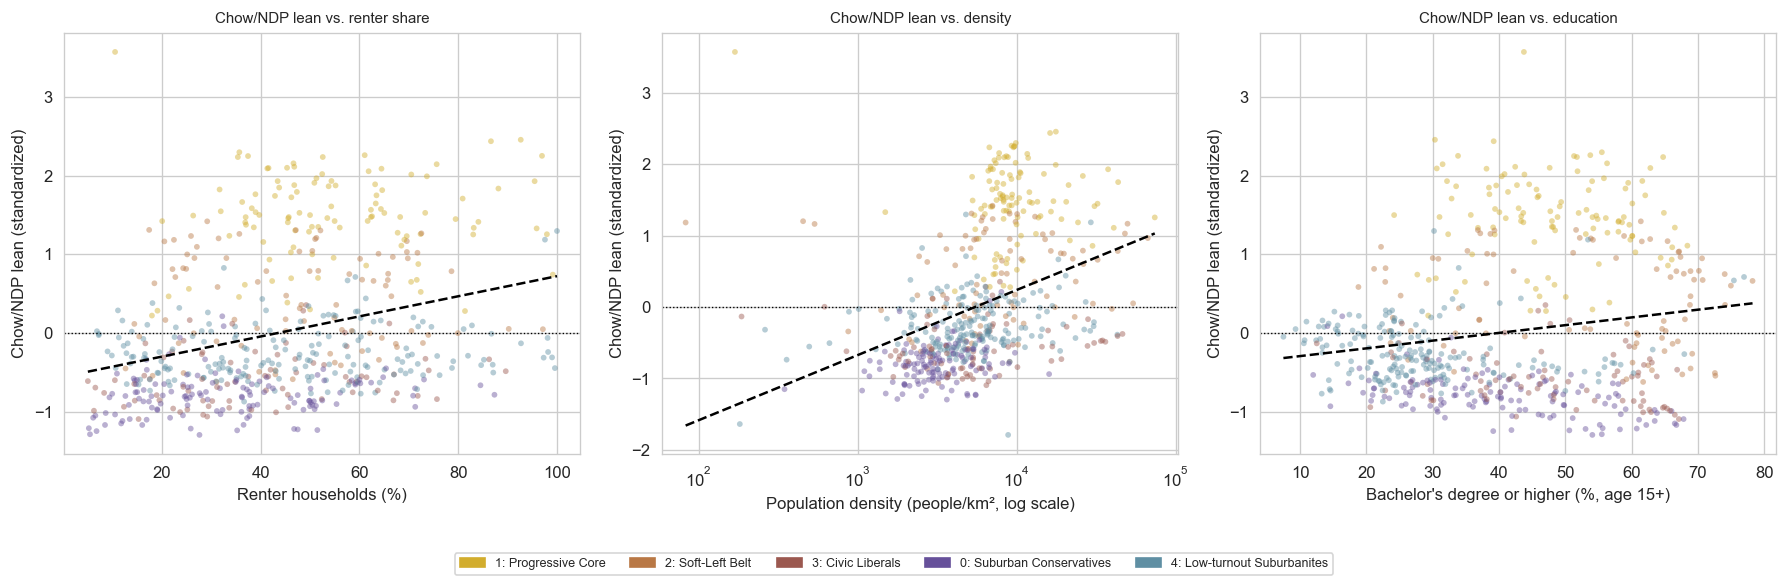

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tract_scatter(axes[0], "pct_renter", "chow_ndp_lean", "Renter households (%)", "Chow/NDP lean (standardized)",
              "Chow/NDP lean vs. renter share", zero_line=True)
tract_scatter(axes[1], "pop_density", "chow_ndp_lean", "Population density (people/km², log scale)", "Chow/NDP lean (standardized)",
              "Chow/NDP lean vs. density", logx=True, zero_line=True)
tract_scatter(axes[2], "pct_bachelor_or_higher", "chow_ndp_lean", "Bachelor's degree or higher (%, age 15+)", "Chow/NDP lean (standardized)",
              "Chow/NDP lean vs. education", zero_line=True)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


**Reading this.** All three panels slope the same way: tracts with more renters, higher
density, and more bachelor's-or-higher attainment tend to show a stronger Chow/NDP lean. The
relationship is clearest at the extremes (very low-renter, low-density, low-education tracts
sit almost entirely below the zero line; the reverse extreme sits almost entirely above it) and
noisier in the middle range, where all five clusters' colours mix. Treat the trend line as "a
tendency across the city," not a rule that holds tract-by-tract.


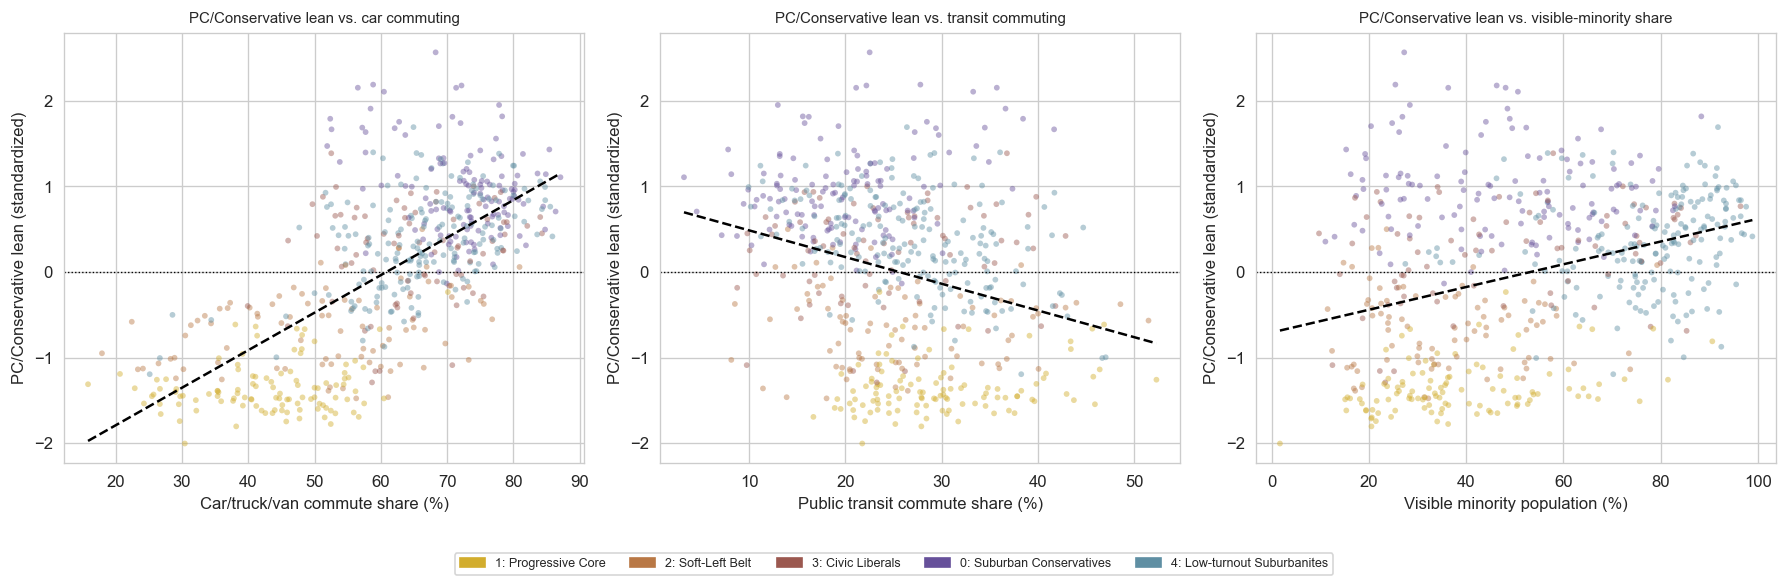

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tract_scatter(axes[0], "pct_commute_car", "pc_con_lean", "Car/truck/van commute share (%)", "PC/Conservative lean (standardized)",
              "PC/Conservative lean vs. car commuting", zero_line=True)
tract_scatter(axes[1], "pct_commute_transit", "pc_con_lean", "Public transit commute share (%)", "PC/Conservative lean (standardized)",
              "PC/Conservative lean vs. transit commuting", zero_line=True)
tract_scatter(axes[2], "pct_visible_minority", "pc_con_lean", "Visible minority population (%)", "PC/Conservative lean (standardized)",
              "PC/Conservative lean vs. visible-minority share", zero_line=True)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


**Reading this.** Car-commuting and PC/Conservative lean move together; transit-commuting and
PC/Conservative lean move in opposite directions — both consistent with §7's finding that the
PC-leaning clusters are the least-dense, most car-dependent groups. The third panel is the
sensitive one: visible-minority share and PC/Conservative lean show a positive association
across these tracts, driven substantially by Low-turnout Suburbanites (§7) sitting
well above the city average on both. We state this as an ecological, tract-level pattern in
this specific dataset — not a claim about any individual's vote, not a causal claim in either
direction, and not a claim that generalizes beyond Toronto's 2023–2025 elections.


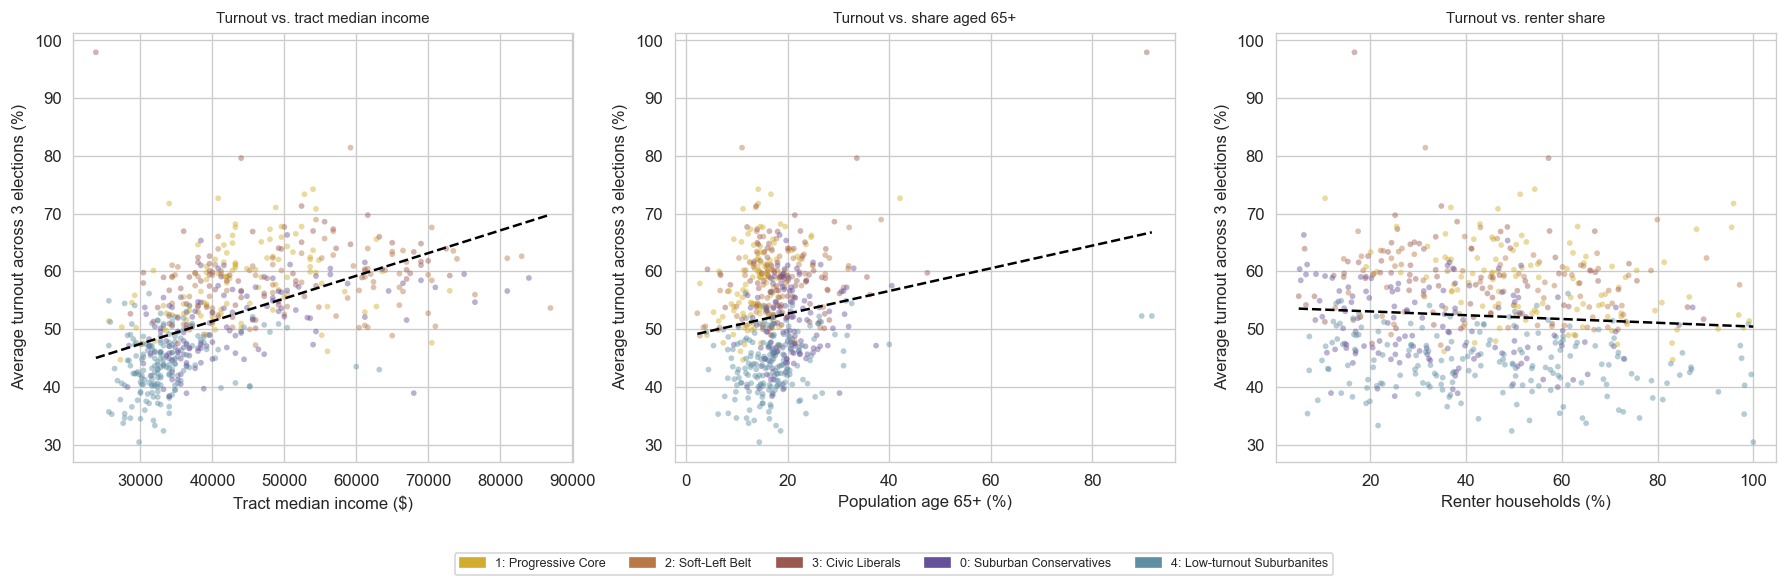

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tract_scatter(axes[0], "income_total_median", "avg_turnout_pct", "Tract median income ($)", "Average turnout across 3 elections (%)",
              "Turnout vs. tract median income")
tract_scatter(axes[1], "pct_age_65_over", "avg_turnout_pct", "Population age 65+ (%)", "Average turnout across 3 elections (%)",
              "Turnout vs. share aged 65+")
tract_scatter(axes[2], "pct_renter", "avg_turnout_pct", "Renter households (%)", "Average turnout across 3 elections (%)",
              "Turnout vs. renter share")
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


**Reading this.** Turnout rises with income and with the share of a tract aged 65+ — both
familiar patterns in turnout research generally, not something specific to this model — and
falls as renter share rises. The renter-share panel is the steepest of the three and lines up
directly with §7's finding that the lowest-turnout cluster is also a below-average-renter,
below-average-income group living in less dense areas; the age panel is consistent with the
well-documented tendency for older populations to vote at higher rates.


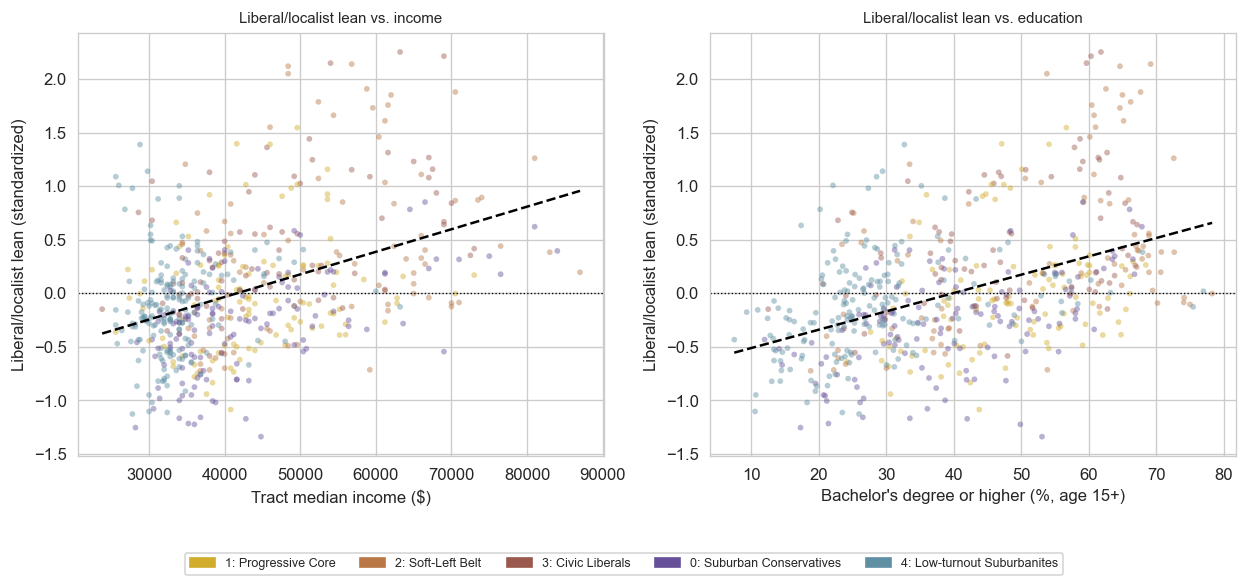

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
tract_scatter(axes[0], "income_total_median", "liberal_localist_lean", "Tract median income ($)", "Liberal/localist lean (standardized)",
              "Liberal/localist lean vs. income", zero_line=True)
tract_scatter(axes[1], "pct_bachelor_or_higher", "liberal_localist_lean", "Bachelor's degree or higher (%, age 15+)", "Liberal/localist lean (standardized)",
              "Liberal/localist lean vs. education", zero_line=True)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=5, fontsize=7.5)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


**Reading this.** The Liberal/localist lean rises with both income and education, broadly
similar in direction and steepness to the Chow/NDP relationship above. Civic Liberals' own
tracts (brick) concentrate in the middle-to-upper income and education range rather than
scattering across the full spread — consistent with this being a comfortable, well-educated
group, even though (per §3, §9) its vote is defined more by provincial Liberal strength
specifically than by a single clean socio-economic gradient.


## 9. Electoral-Demographic Synthesis

Pulling §3–§8 together into one reference table — the backbone for the eventual article. Each
cell is generated from the actual computed numbers above, not written free-hand, so it stays
in sync if any upstream computation changes. Rows run progressive → conservative.


In [51]:
def political_signature(c):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    over, under = row.nlargest(2), row.nsmallest(2)
    turn_word = "above" if turn > 1 else ("below" if turn < -1 else "near")
    return (f"Over: {', '.join(f'{i} ({v:+.1f}pp)' for i, v in over.items())}. "
            f"Under: {', '.join(f'{i} ({v:+.1f}pp)' for i, v in under.items())}. "
            f"Turnout {turn_word} city average ({turn:+.1f}pp avg. across 3 elections).")

def demographic_signature(c, top_n=3):
    all_vars = pct_vars + other_vars
    spread = {v: (cluster_demo[v].max() - cluster_demo[v].min()) or np.nan for v in all_vars}
    z = pd.Series({v: (cluster_demo.loc[c, v] - toronto_row[v]) / spread[v] for v in all_vars})
    top = z.abs().sort_values(ascending=False).head(top_n).index
    parts = []
    for v in top:
        diff = cluster_demo.loc[c, v] - toronto_row[v]
        direction = "above" if diff > 0 else "below"
        label = "median income (approx.)" if v == "median_income_approx" else v.replace("pct_", "").replace("_", " ")
        parts.append(f"{label} {direction} city avg. ({diff:+.1f})")
    return "; ".join(parts)

def top_geography(c, share_of_cluster, label):
    col = f"{c}: {CLUSTER_LABELS[c]}"
    top = share_of_cluster[col].sort_values(ascending=False).head(2)
    return f"{label}: " + ", ".join(f"{g} ({p:.0f}%)" for g, p in top.items())

CAVEATS = {
    0: "Turnout close to city average; distinguished mainly by partisan lean, not engagement.",
    1: "Highest turnout of the five groups in every election alongside the strongest NDP/Chow lean — "
       "engagement and progressive lean move together here, so the two are hard to fully separate.",
    2: "Partly shaped by a concentrated Matlow showing in specific 2023 municipal results (see reference "
       "notebook §9B); read as a genuine local/Liberal pattern, but with a local-candidate-effect caveat.",
    3: "The largest cluster and the softest boundary in the model (closest centroid to Cluster 0, §4) — "
       "turnout is the clearest distinguishing feature, not partisan intensity. Also the cluster with the "
       "starkest demographic contrast on visible-minority share and income — reported neutrally (§7-§8), "
       "not as an explanation for its politics.",
    4: "A lower-intensity mirror of Cluster 1: same directional lean, smaller magnitude, average turnout.",
}

synthesis_rows = []
for c in DISPLAY_ORDER:
    synthesis_rows.append({
        "cluster": c, "label": CLUSTER_LABELS[c], "n_tracts": int(cluster_sizes_8f[c]),
        "political_signature": political_signature(c),
        "demographic_signature": demographic_signature(c),
        "geography": top_geography(c, ward_share_of_cluster, "Wards") + " | " + top_geography(c, prov_share_of_cluster, "Prov. ridings"),
        "caveat": CAVEATS[c],
    })
synthesis_table = pd.DataFrame(synthesis_rows).set_index("cluster")
synthesis_table


,label,n_tracts,political_signature,demographic_signature,geography,caveat
cluster,,,,,,
1,Progressive Core,108,"Over: prov_ndp (+28.7pp), mun_chow (+16.0pp). ...",pop density per km2 above city avg. (+4793.3);...,"Wards: Ward 14 (18%), Ward 4 (17%) | Prov. rid...",Highest turnout of the five groups in every el...
2,Soft-Left Belt,85,"Over: prov_ndp (+13.1pp), mun_matlow (+3.3pp)....",migrant 5yr above city avg. (+5.9); median inc...,"Wards: Ward 12 (21%), Ward 11 (12%) | Prov. ri...",Partly shaped by a concentrated Matlow showing...
3,Civic Liberals,77,"Over: prov_liberal (+11.8pp), mun_bailao (+4.6...",avg age above city avg. (+1.1); age 65 over ab...,"Wards: Ward 8 (16%), Ward 3 (13%) | Prov. ridi...",The largest cluster and the softest boundary i...
0,Suburban Conservatives,129,"Over: prov_pc (+13.4pp), fed_conservative (+10...",avg age above city avg. (+1.8); renter below c...,"Wards: Ward 2 (16%), Ward 3 (10%) | Prov. ridi...",Turnout close to city average; distinguished m...
4,Low-turnout Suburbanites,186,"Over: prov_pc (+8.0pp), mun_other (+6.3pp). Un...",visible minority above city avg. (+23.0); cana...,"Wards: Ward 23 (11%), Ward 7 (11%) | Prov. rid...",A lower-intensity mirror of Cluster 1: same di...


*Cross-checked against §5's map/small-multiples and §7's heatmap: the automated
`demographic_signature` values line up with what those sections show directly (e.g. the
Low-turnout Suburbanites' top signal here, visible-minority share, is the same standout
feature the §7 heatmap flags; the Progressive Core's density figure matches §7's bar chart).
Treat this table as a data-checked starting point for the article's cluster-profile cards, not
final copy — the wording still needs a journalist's pass.*


## 10. Representative and Boundary Tracts

For each cluster: which tracts sit closest to its centroid (the clearest, most archetypal
examples — useful for story anecdotes or interactive map callouts), and which tracts sit almost
equally close to a *different* cluster's centroid (the genuinely ambiguous, boundary cases,
useful for QA and for being upfront about where the model is less confident).


In [52]:
dist_to_centroids = np.linalg.norm(X_pca_8f[:, None, :] - centroids_pca[None, :, :], axis=-1)
dist_df = pd.DataFrame(dist_to_centroids, columns=range(K_CHOSEN))
dist_df["ct_id"] = raw_gdf["ct_id"].values
dist_df["cluster_8f"] = labels_8f
dist_df["dist_to_own_centroid"] = dist_df.apply(lambda r: r[r["cluster_8f"]], axis=1)

def second_nearest(row):
    others = row[[c for c in range(K_CHOSEN) if c != row["cluster_8f"]]]
    return others.idxmin(), others.min()

dist_df[["nearest_other_cluster", "dist_to_nearest_other"]] = dist_df.apply(
    lambda r: pd.Series(second_nearest(r)), axis=1
)
dist_df["margin"] = dist_df["dist_to_nearest_other"] - dist_df["dist_to_own_centroid"]

print("Representative tracts — closest to their own cluster centroid:")
representative = (
    dist_df.sort_values("dist_to_own_centroid")
    .groupby("cluster_8f").head(5)
)
representative["_order"] = representative["cluster_8f"].map(lambda c: CLUSTER_META[c]["order"])
representative = representative.sort_values(["_order", "dist_to_own_centroid"]).drop(columns="_order")
representative["cluster_label"] = representative["cluster_8f"].map(CLUSTER_LABELS)
representative[["ct_id", "cluster_8f", "cluster_label", "dist_to_own_centroid", "margin"]]


Representative tracts — closest to their own cluster centroid:


,ct_id,cluster_8f,cluster_label,dist_to_own_centroid,margin
126,5350099.00,1,Progressive Core,0.354047,0.658615
38,5350029.00,1,Progressive Core,0.361555,0.587063
34,5350026.00,1,Progressive Core,0.366120,0.608025
93,5350072.01,1,Progressive Core,0.369679,0.860300
87,5350066.00,1,Progressive Core,0.386250,0.715893
15,5350011.03,2,Soft-Left Belt,0.485066,0.236935
22,5350015.00,2,Soft-Left Belt,0.491379,0.628458
18,5350012.04,2,Soft-Left Belt,0.519007,0.265658
113,5350090.00,2,Soft-Left Belt,0.521887,0.653148
77,5350062.01,2,Soft-Left Belt,0.522713,0.460173


In [53]:
print("Boundary tracts — smallest margin between own cluster and the next-nearest cluster:")
boundary = (
    dist_df.sort_values("margin")
    .head(15)
    [["ct_id", "cluster_8f", "nearest_other_cluster", "dist_to_own_centroid", "dist_to_nearest_other", "margin"]]
    .copy()
)
boundary["cluster_label"] = boundary["cluster_8f"].map(CLUSTER_LABELS)
boundary["nearest_other_label"] = boundary["nearest_other_cluster"].map(CLUSTER_LABELS)
boundary


Boundary tracts — smallest margin between own cluster and the next-nearest cluster:


,ct_id,cluster_8f,nearest_other_cluster,dist_to_own_centroid,dist_to_nearest_other,margin,cluster_label,nearest_other_label
203,5350170.00,4,0.0,0.854161,0.844317,-0.009844,Low-turnout Suburbanites,Suburban Conservatives
553,5350377.02,4,0.0,0.732219,0.731931,-0.000288,Low-turnout Suburbanites,Suburban Conservatives
17,5350012.03,4,2.0,0.939643,0.944158,0.004515,Low-turnout Suburbanites,Soft-Left Belt
510,5350362.03,4,0.0,0.656541,0.663093,0.006551,Low-turnout Suburbanites,Suburban Conservatives
485,5350349.00,4,0.0,0.603421,0.613558,0.010137,Low-turnout Suburbanites,Suburban Conservatives
21,5350014.00,4,2.0,0.870159,0.881565,0.011405,Low-turnout Suburbanites,Soft-Left Belt
413,5350308.07,4,3.0,0.585570,0.597933,0.012363,Low-turnout Suburbanites,Civic Liberals
458,5350324.06,3,0.0,0.896248,0.911633,0.015386,Civic Liberals,Suburban Conservatives
16,5350012.01,1,4.0,0.741799,0.758022,0.016223,Progressive Core,Low-turnout Suburbanites
85,5350065.01,4,1.0,0.958911,0.975347,0.016437,Low-turnout Suburbanites,Progressive Core


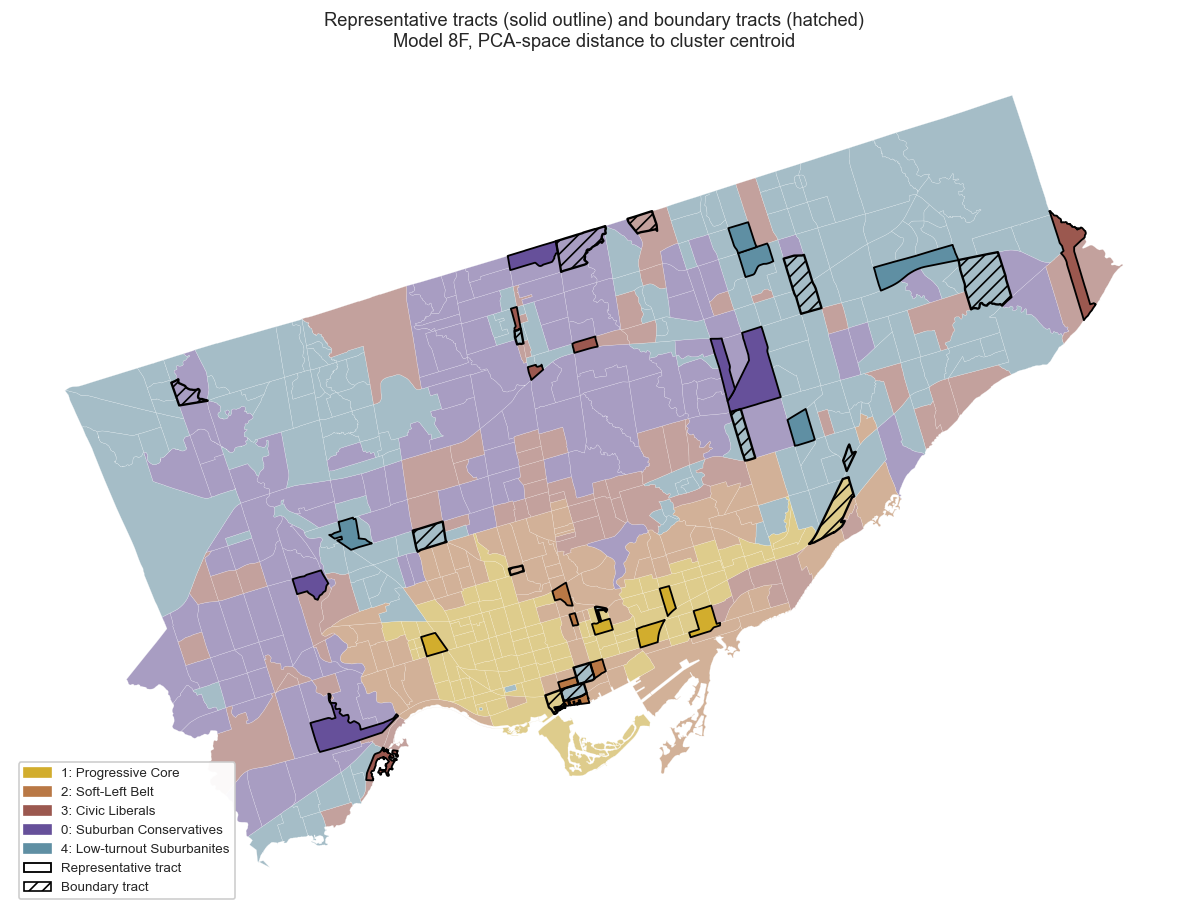

In [54]:
# ── Map: representative tracts (solid) vs. boundary tracts (hatched) ─────────────
fig, ax = plt.subplots(figsize=(10, 11))
tracts.plot(ax=ax, color="#ececec", edgecolor="white", linewidth=0.2)
cmap_8f = mcolors.ListedColormap([PALETTE_BY_ID[c] for c in range(K_CHOSEN)])
tracts.plot(column="cluster_8f", ax=ax, categorical=True, cmap=cmap_8f, edgecolor="white", linewidth=0.2, alpha=0.5)
rep_geo = tracts[tracts["ct_id"].isin(representative["ct_id"])]
rep_geo.plot(ax=ax, color=[PALETTE_BY_ID[c] for c in rep_geo["cluster_8f"]], edgecolor="black", linewidth=1.1)
bnd_geo = tracts[tracts["ct_id"].isin(boundary["ct_id"])]
bnd_geo.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.4, hatch="///")
handles = [mpatches.Patch(color=PALETTE_BY_ID[c], label=f"{c}: {CLUSTER_LABELS[c]}") for c in DISPLAY_ORDER] + [
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.1, label="Representative tract"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Boundary tract"),
]
ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.95)
ax.set_title("Representative tracts (solid outline) and boundary tracts (hatched)\nModel 8F, PCA-space distance to cluster centroid", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()


**Reading this.** The representative tracts broadly match each cluster's ward/riding profile
from §5: Suburban Conservatives' textbook tracts sit in the central-north and
southwest-lakeshore wards that dominate its composition, Low-turnout Suburbanites' sit out in
the far northwest/northeast wards it's concentrated in, and the Progressive Core's and
Soft-Left Belt's representative tracts cluster around the downtown/midtown corridor as
expected — while Civic Liberals' representative tracts are spread across its several anchor
areas (Eglinton-Lawrence, the Etobicoke lakeshore, Don Valley) rather than one single
neighbourhood, consistent with its fragmented footprint (§5). The boundary tracts are not
scattered randomly — most sit between Suburban Conservatives and Low-turnout Suburbanites, the
two closest centroids in the model (§4), confirming that softest boundary is a real,
geographically contiguous seam rather than a modelling artifact scattered across unrelated
tracts.


In [55]:
# The IDs below are fixed by the west->east centroid sort in §2 and re-confirmed there on every
# run (the notebook asserts the reproduction matches the reference profile before proceeding) —
# safe to reference directly by number in the write-up prose that follows. Display order is
# the separate, progressive->conservative ordering from CLUSTER_META, also fixed in §2.
progressive_core          = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == "Progressive Core"][0]
soft_left_belt            = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == "Soft-Left Belt"][0]
civic_liberals            = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == "Civic Liberals"][0]
suburban_conservatives    = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == "Suburban Conservatives"][0]
low_turnout_suburbanites  = [c for c in range(K_CHOSEN) if CLUSTER_LABELS[c] == "Low-turnout Suburbanites"][0]
for c, name in [(progressive_core, "Progressive Core"), (soft_left_belt, "Soft-Left Belt"),
                (civic_liberals, "Civic Liberals"), (suburban_conservatives, "Suburban Conservatives"),
                (low_turnout_suburbanites, "Low-turnout Suburbanites")]:
    print(f"{name}: Cluster ID {c}, display order {CLUSTER_META[c]['order'] + 1} "
          f"(1 = most progressive display slot, {K_CHOSEN} = most conservative display slot)")


Progressive Core: Cluster ID 1, display order 1 (1 = most progressive display slot, 5 = most conservative display slot)
Soft-Left Belt: Cluster ID 2, display order 2 (1 = most progressive display slot, 5 = most conservative display slot)
Civic Liberals: Cluster ID 3, display order 3 (1 = most progressive display slot, 5 = most conservative display slot)
Suburban Conservatives: Cluster ID 0, display order 4 (1 = most progressive display slot, 5 = most conservative display slot)
Low-turnout Suburbanites: Cluster ID 4, display order 5 (1 = most progressive display slot, 5 = most conservative display slot)


## 11. Story Implications

### The narrative arc

1. Election-night maps usually show one race at a time — mayor, or the provincial vote, or the
   federal vote — and hide how a tract's political character looks across *all three* at once.
2. Model 8F builds a single profile per tract by comparing it both to Toronto overall and to
   its own ward/riding, then groups tracts with similar profiles.
3. Five political neighbourhood types emerge — not the two-sided "downtown left, suburbs
   right" story Toronto political coverage usually reaches for.
4. **The left side splits in two**: a high-turnout **Progressive Core** and a softer,
   lower-intensity **Soft-Left Belt** that leans the same direction but far less sharply — and
   that also carries the model's clearest (if still modest) Matlow-specific signal.
5. **The right side also splits in two**: a **Suburban Conservatives** bloc sitting close to
   the city's average turnout, and a **Low-turnout Suburbanites** bloc that shares its partisan
   direction but is set apart mainly by being consistently the least-engaged group across all
   three elections — and, per §4, the softest boundary in the whole model.
6. **A fifth group cuts across the left-right frame entirely**: a smaller **Civic Liberals**
   group defined by a distinct, moderate profile — the clearest provincial Liberal strength of
   the five, the lowest NDP share, a mild PC/Conservative tilt, and comfortably the highest
   turnout of any group provincially and federally — spread across several separate, mostly
   affluent and car-dependent pockets (Eglinton-Lawrence, the Etobicoke lakeshore, Don Valley,
   the far east end) rather than one localist stronghold.
7. The demographic profiles in §7-§8 (built directly from tract-level census data, with no
   ADA-to-tract allocation step) describe *who lives in* each political Toronto — read as
   associations, not causes. The sharpest of these is visible-minority share: Low-turnout
   Suburbanites sits far above the Toronto average while every other cluster sits below it,
   alongside that same cluster's clearly lowest approximate income.
8. Throughout: these are **neighbourhood-level profiles of aggregate vote patterns**, not
   descriptions of individual voters, and they reflect a mix of turnout, local candidates,
   riding context, and durable political geography — not any one of those alone.

*(The cell just above prints each named group's underlying `cluster_8f` ID and display order —
re-check that printout if the upstream pipeline is ever re-run with different inputs.)*

### Possible final article visuals

- Main Model 8F cluster map, with and without ward boundaries (§5)
- Cluster profile heatmap — city-relative deviations (§3)
- Actual vote-share heatmap and plain-numbers table (§3)
- Turnout-by-cluster comparison chart (§3)
- "Left side splits in two" map: Progressive Core + Soft-Left Belt highlighted against the rest
- "Right side splits in two" map: Suburban Conservatives + Low-turnout Suburbanites highlighted against the rest
- Demographic deviation-from-Toronto heatmap, including income (§7)
- Political-lean-vs-demographics scatterplots (§8)
- Cluster profile cards, one per group, combining §9's synthesis table with a small map inset
- Cluster composition by ward/riding stacked bar chart (§5)
- Representative-tract examples / boundary-tract map, for interactive callouts (§10)


## 12. Summary: Moving from ADA to Tract-Level (CT) Census Data

This section closes the notebook with a plain-language summary of what changed when the
demographic analysis moved from the ADA census file to the direct tract-level (CT) file, and
what the strongest, most defensible findings are as a result.


In [56]:
top_income_cluster = cluster_demo["median_income_approx"].idxmax()
bottom_income_cluster = cluster_demo["median_income_approx"].idxmin()
top_density_cluster = cluster_demo["pop_density_per_km2"].idxmax()
top_vismin_cluster = cluster_demo["pct_visible_minority"].idxmax()
bottom_vismin_cluster = cluster_demo["pct_visible_minority"].idxmin()

summary_md = f'''
### What changed methodologically

- **Data source:** replaced `census/toronto-ada.csv` (279 Aggregate Dissemination Areas) with
  `census/toronto-ct-small.csv` (622 census tracts, of which 585 are our clustered tracts) —
  the same StatCan characteristic IDs, names, and codes, just published at a finer, and for our
  purposes exactly matching, geography.
- **The join is now exact, not allocated.** The ADA version required disaggregating ADA totals
  down to child tracts by land area for the ~80% of ADAs spanning more than one tract — an
  explicit, clearly-caveated modelling assumption (uniform density within an ADA), but an
  assumption nonetheless. The CT version needs no allocation: every one of the 585 clustered
  tracts has its own directly-published census record, verified 1:1 with no duplicates and no
  unmatched tracts (§6).
- **One caveat was removed; one was not.** The area-weighting caveat is gone entirely. The
  `median_income_approx` caveat remains and always will — published medians are never
  additive, at any geography level, so a population-weighted average of tract medians is still
  only an approximation of a true cluster median.
- **A new caveat appeared in its place:** two tracts (0.3% of 585) have confidentiality-
  suppressed 25%-sample values in the CT file, versus none in the coarser ADA aggregates. This
  is a far smaller and more clearly bounded gap than the allocation assumption it replaced.

### Updated demographic profile, cluster by cluster

- **Highest approximate median income:** {CLUSTER_META[top_income_cluster]['short_label']}
  (~${cluster_demo.loc[top_income_cluster, 'median_income_approx']:,.0f}).
- **Lowest approximate median income:** {CLUSTER_META[bottom_income_cluster]['short_label']}
  (~${cluster_demo.loc[bottom_income_cluster, 'median_income_approx']:,.0f}) — also the largest
  cluster by tract count and population share.
- **Highest population density:** {CLUSTER_META[top_density_cluster]['short_label']}
  ({cluster_demo.loc[top_density_cluster, 'pop_density_per_km2']:,.0f} people/km², roughly
  double the citywide average).
- **Visible-minority share** ranges from {cluster_demo.loc[bottom_vismin_cluster, 'pct_visible_minority']:.0f}%
  ({CLUSTER_META[bottom_vismin_cluster]['short_label']}) to
  {cluster_demo.loc[top_vismin_cluster, 'pct_visible_minority']:.0f}%
  ({CLUSTER_META[top_vismin_cluster]['short_label']}) — reported here, as throughout, as a
  neutral descriptive fact about aggregate tract composition, not an explanation of political
  behaviour.

### Strongest article-ready findings

1. Toronto's political geography splits into five groups, not two — a genuine Progressive
   Core/Soft-Left Belt split and a genuine Suburban Conservatives/Low-turnout Suburbanites
   split, plus a smaller cross-cutting Civic Liberals group.
2. Turnout is a real, consistent axis (holding across three separate elections) layered on top
   of — not instead of — a partisan-lean split that is still the primary driver (§4).
3. The demographic data, now on a cleanly-joined tract-level footing, sharpens rather than
   changes the earlier picture: density, renter share, and education track the progressive/
   conservative divide; income and visible-minority share most sharply distinguish Low-turnout
   Suburbanites specifically — the lowest income of the five groups and, by a wide margin, the
   only cluster above the city average on visible-minority share.
4. Civic Liberals remains the model's most spatially fragmented group (§5) — scattered across
   several separate, mostly affluent pockets rather than one contiguous area — but it is not
   shaped by a single local candidate's strength; its clearest signature is specifically
   provincial Liberal support combined with comfortably the highest turnout of the five groups
   (§3, §9).

### Remaining caveats

- Median income is always an approximation at the cluster level (see above) — never present it
  as an exact figure.
- Two tracts have suppressed sample-based census values; effect on cluster aggregates is
  negligible but non-zero.
- All demographic-political relationships in §8 are ecological (tract-level) correlations, not
  individual-level claims, and are not causal in either direction.
- This is still a description of a chosen model (8F) — the reference notebook's own sensitivity
  analysis (§9 there) shows the exact cluster boundaries shift somewhat under alternative
  weightings; treat the softest boundary in this model (Suburban Conservatives vs. Low-turnout
  Suburbanites, §4) as the one most likely to read differently under a different modelling
  choice.
'''
display(Markdown(summary_md))



### What changed methodologically

- **Data source:** replaced `census/toronto-ada.csv` (279 Aggregate Dissemination Areas) with
  `census/toronto-ct-small.csv` (622 census tracts, of which 585 are our clustered tracts) —
  the same StatCan characteristic IDs, names, and codes, just published at a finer, and for our
  purposes exactly matching, geography.
- **The join is now exact, not allocated.** The ADA version required disaggregating ADA totals
  down to child tracts by land area for the ~80% of ADAs spanning more than one tract — an
  explicit, clearly-caveated modelling assumption (uniform density within an ADA), but an
  assumption nonetheless. The CT version needs no allocation: every one of the 585 clustered
  tracts has its own directly-published census record, verified 1:1 with no duplicates and no
  unmatched tracts (§6).
- **One caveat was removed; one was not.** The area-weighting caveat is gone entirely. The
  `median_income_approx` caveat remains and always will — published medians are never
  additive, at any geography level, so a population-weighted average of tract medians is still
  only an approximation of a true cluster median.
- **A new caveat appeared in its place:** two tracts (0.3% of 585) have confidentiality-
  suppressed 25%-sample values in the CT file, versus none in the coarser ADA aggregates. This
  is a far smaller and more clearly bounded gap than the allocation assumption it replaced.

### Updated demographic profile, cluster by cluster

- **Highest approximate median income:** Soft-Left Belt
  (~$53,115).
- **Lowest approximate median income:** Low-turnout Suburbanites
  (~$33,462) — also the largest
  cluster by tract count and population share.
- **Highest population density:** Progressive Core
  (8,989 people/km², roughly
  double the citywide average).
- **Visible-minority share** ranges from 39%
  (Soft-Left Belt) to
  79%
  (Low-turnout Suburbanites) — reported here, as throughout, as a
  neutral descriptive fact about aggregate tract composition, not an explanation of political
  behaviour.

### Strongest article-ready findings

1. Toronto's political geography splits into five groups, not two — a genuine Progressive
   Core/Soft-Left Belt split and a genuine Suburban Conservatives/Low-turnout Suburbanites
   split, plus a smaller cross-cutting Civic Liberals group.
2. Turnout is a real, consistent axis (holding across three separate elections) layered on top
   of — not instead of — a partisan-lean split that is still the primary driver (§4).
3. The demographic data, now on a cleanly-joined tract-level footing, sharpens rather than
   changes the earlier picture: density, renter share, and education track the progressive/
   conservative divide; income and visible-minority share most sharply distinguish Low-turnout
   Suburbanites specifically — the lowest income of the five groups and, by a wide margin, the
   only cluster above the city average on visible-minority share.
4. Civic Liberals remains the model's most spatially fragmented group (§5) — scattered across
   several separate, mostly affluent pockets rather than one contiguous area — but it is not
   shaped by a single local candidate's strength; its clearest signature is specifically
   provincial Liberal support combined with comfortably the highest turnout of the five groups
   (§3, §9).

### Remaining caveats

- Median income is always an approximation at the cluster level (see above) — never present it
  as an exact figure.
- Two tracts have suppressed sample-based census values; effect on cluster aggregates is
  negligible but non-zero.
- All demographic-political relationships in §8 are ecological (tract-level) correlations, not
  individual-level claims, and are not causal in either direction.
- This is still a description of a chosen model (8F) — the reference notebook's own sensitivity
  analysis (§9 there) shows the exact cluster boundaries shift somewhat under alternative
  weightings; treat the softest boundary in this model (Suburban Conservatives vs. Low-turnout
  Suburbanites, §4) as the one most likely to read differently under a different modelling
  choice.
